In [5]:
#Librerias
import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
#carga_de_datos
def cargar_datos_csv_listas(ruta_archivo):
    FSC_A = [] ;     SSC_A = [] ;    FL1_A = [] ;    FL2_A = [];     FL3_A = [] ;     FL4_A = []
    FSC_H = [];    SSC_H = [];    FL1_H = [];    FL2_H = [];    FL3_H = [];    FL4_H = []
    
    Width = [];    Time = []
    
    with open(ruta_archivo, newline='') as archivo:  #
        lector = csv.reader(archivo)
        next(lector)  
        
        for fila in lector:
            FSC_A.append(int(fila[0]))
            SSC_A.append(int(fila[1]))
            FL1_A.append(int(fila[2]))
            FL2_A.append(int(fila[3]))
            FL3_A.append(int(fila[4]))
            FL4_A.append(int(fila[5]))
            FSC_H.append(int(fila[6]))
            SSC_H.append(int(fila[7]))
            FL1_H.append(int(fila[8]))
            FL2_H.append(int(fila[9]))
            FL3_H.append(int(fila[10]))
            FL4_H.append(int(fila[11]))
            Width.append(int(fila[12]))
            Time.append(int(fila[13]))
    
    return (FSC_A, SSC_A, FL1_A, FL2_A, FL3_A, FL4_A,
            FSC_H, SSC_H, FL1_H, FL2_H, FL3_H, FL4_H,
            Width, Time)

In [4]:
colores = {
    'glucosa': '#480058',
    'glicerol_etanol': '#4B75FF',
    'glicerol': '#FFA213',
    'glucosa_etanol': '#B72818',
    'cepaSB10_LB': '#480058',
    'cepaSB10_LBE': '#4B75FF',
    'cepapMS201_LB': '#FFA213',
    'cepapMS201_LBE': '#B72818'
}

estilos = {
    'glucosa': '-.',
    'glicerol_etanol': ':',
    'glicerol': '-',
    'glucosa_etanol': '--',
    'cepaSB10_LB': '-.',
    'cepaSB10_LBE': ':',
    'cepa3_LB': '-',
    'cepa4_LB': '--'
}

In [ ]:
def grafica_scatter(datos_dict, nombre_base):
    """
    Genera y guarda la gráfica scatter (2x2).
    """
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()

    save_path_scatter = os.path.join(script_dir, f"{nombre_base}_scatter.png")

    # 1. Creamos la figura y los ejes PRIMERO
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # 2. Ponemos el título general de la figura (supratítulo)
    fig.suptitle("Medidas de Tamaño vs Granularidad", fontsize=35, fontweight='bold', y=0.98)
    
    axes = axes.flatten()

    for i, (nombre, datos) in enumerate(datos_dict.items()):
        FL1_A, FSC_H, SSC_H = datos
        ax = axes[i]

        mask = (np.array(FSC_H) > 0) & (np.array(SSC_H) > 0)
        fsc_filtered = np.array(FSC_H)[mask]
        ssc_filtered = np.array(SSC_H)[mask]

        ax.scatter(
            fsc_filtered,
            ssc_filtered,
            s=15,
            alpha=0.5,
            c=colores.get(nombre, 'blue'),
            marker='.'
        )

        ax.set_xscale('log')
        ax.set_yscale('log')

        nombre_bonito = nombre.replace("_", " ").title()

        ax.set_title(nombre_bonito ", fontsize=30, fontweight='bold', pad=15)
        ax.set_xlabel('FSC-H (Tamaño celular)', fontsize=30, labelpad=15)
        ax.set_ylabel('SSC-H (Granularidad)', fontsize=30, labelpad=15)
        
        ax.tick_params(axis='both', which='major', labelsize=30)
        ax.grid(True, alpha=0.2, which='both')

    # 3. Ajustes de espaciado FUERA del bucle
    plt.subplots_adjust(
        hspace=0.4, 
        wspace=0.3,
        top=0.5,    
        bottom=0.1
    )
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para no tapar el suptitle
    fig.savefig(save_path_scatter, dpi=300, bbox_inches='tight')

    print(f"Scatter guardado: {save_path_scatter}")

    return fig

In [13]:
def grafica_histograma(datos_dict, nombre_base):
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()

    save_path_hist = os.path.join(script_dir, f"{nombre_base}_histogram.png")
    
    fig, ax_main = plt.subplots(figsize=(20, 15))
    
    # 1. Ajustar márgenes para dar espacio al título y etiquetas grandes
    plt.subplots_adjust(top=0.90, bottom=0.15, left=0.15, right=0.95)
    
    fig.suptitle('Conteo de Células Fluorescentes', fontsize=40, fontweight='bold')
    
    # 2. Zoom posicionado (mejor posición para que no estorbe)
    # [x_izq, y_abajo, ancho, alto]
    ax_zoom = fig.add_axes([0.50, 0.45, 0.35, 0.40]) 

    for nombre, (FL1_A, FSC_H, SSC_H) in datos_dict.items():
        datos_array = np.array([x for x in FL1_A if x > 0])
        datos_zoom = datos_array[datos_array > 1500]
        color_f = colores.get(nombre, 'blue')
        label_bonito = nombre.replace("_", " ").title()

        ax_main.hist(datos_array, bins=150, color=color_f, alpha=0.3, edgecolor=color_f, linewidth=2, 
                     label=f"{label_bonito} ", histtype='stepfilled')
        ax_zoom.hist(datos_zoom, bins=80, color=color_f, alpha=0.7, edgecolor=color_f, linewidth=2, 
                     histtype='stepfilled')

    # Estilos Ejes Main
    ax_main.set_xlabel('FL1-A (Área de Fluorescencia)', fontsize=40, fontweight='bold', labelpad=20)
    ax_main.set_ylabel('Conteo de Partículas', fontsize=40, fontweight='bold', labelpad=20)
    ax_main.tick_params(axis='both', which='major', labelsize=30) # Números en 30 para no saturar
    ax_main.legend(loc='upper right', fontsize=25, title="Medios", title_fontsize=30)
    ax_main.grid(True, alpha=0.3)
    
    # Estilos Zoom
    ax_zoom.set_title('Población más Luminiscente (>1500)', fontsize=30, fontweight='bold', pad=15)
    ax_zoom.tick_params(axis='both', which='major', labelsize=20) # Números más pequeños en el zoom
    ax_zoom.grid(True, alpha=0.3)
    ax_main.legend(
        loc='upper left', 
        bbox_to_anchor=(0.6, 0.30), # x=0.55 alinea con el inicio del zoom, y=0.40 es debajo de él
        fontsize=20, 
        title="Medios", 
        title_fontsize=25,
        frameon=True # Poner fondo para que no se pierda con las barras si se enciman
    )
    ax_zoom.set_xlim(1500, 25000) # Limitar el eje x del zoom para enfocarnos en la parte más luminiscente
     # Reposicionar la leyenda del zoom para que no se superponga con las barras
    
    ax_main.set_xlim(-1000, 40000) # Limitar el eje x del histograma principal para enfocarnos en la parte relevante
    fig.savefig(save_path_hist, dpi=300, bbox_inches='tight')
    return fig

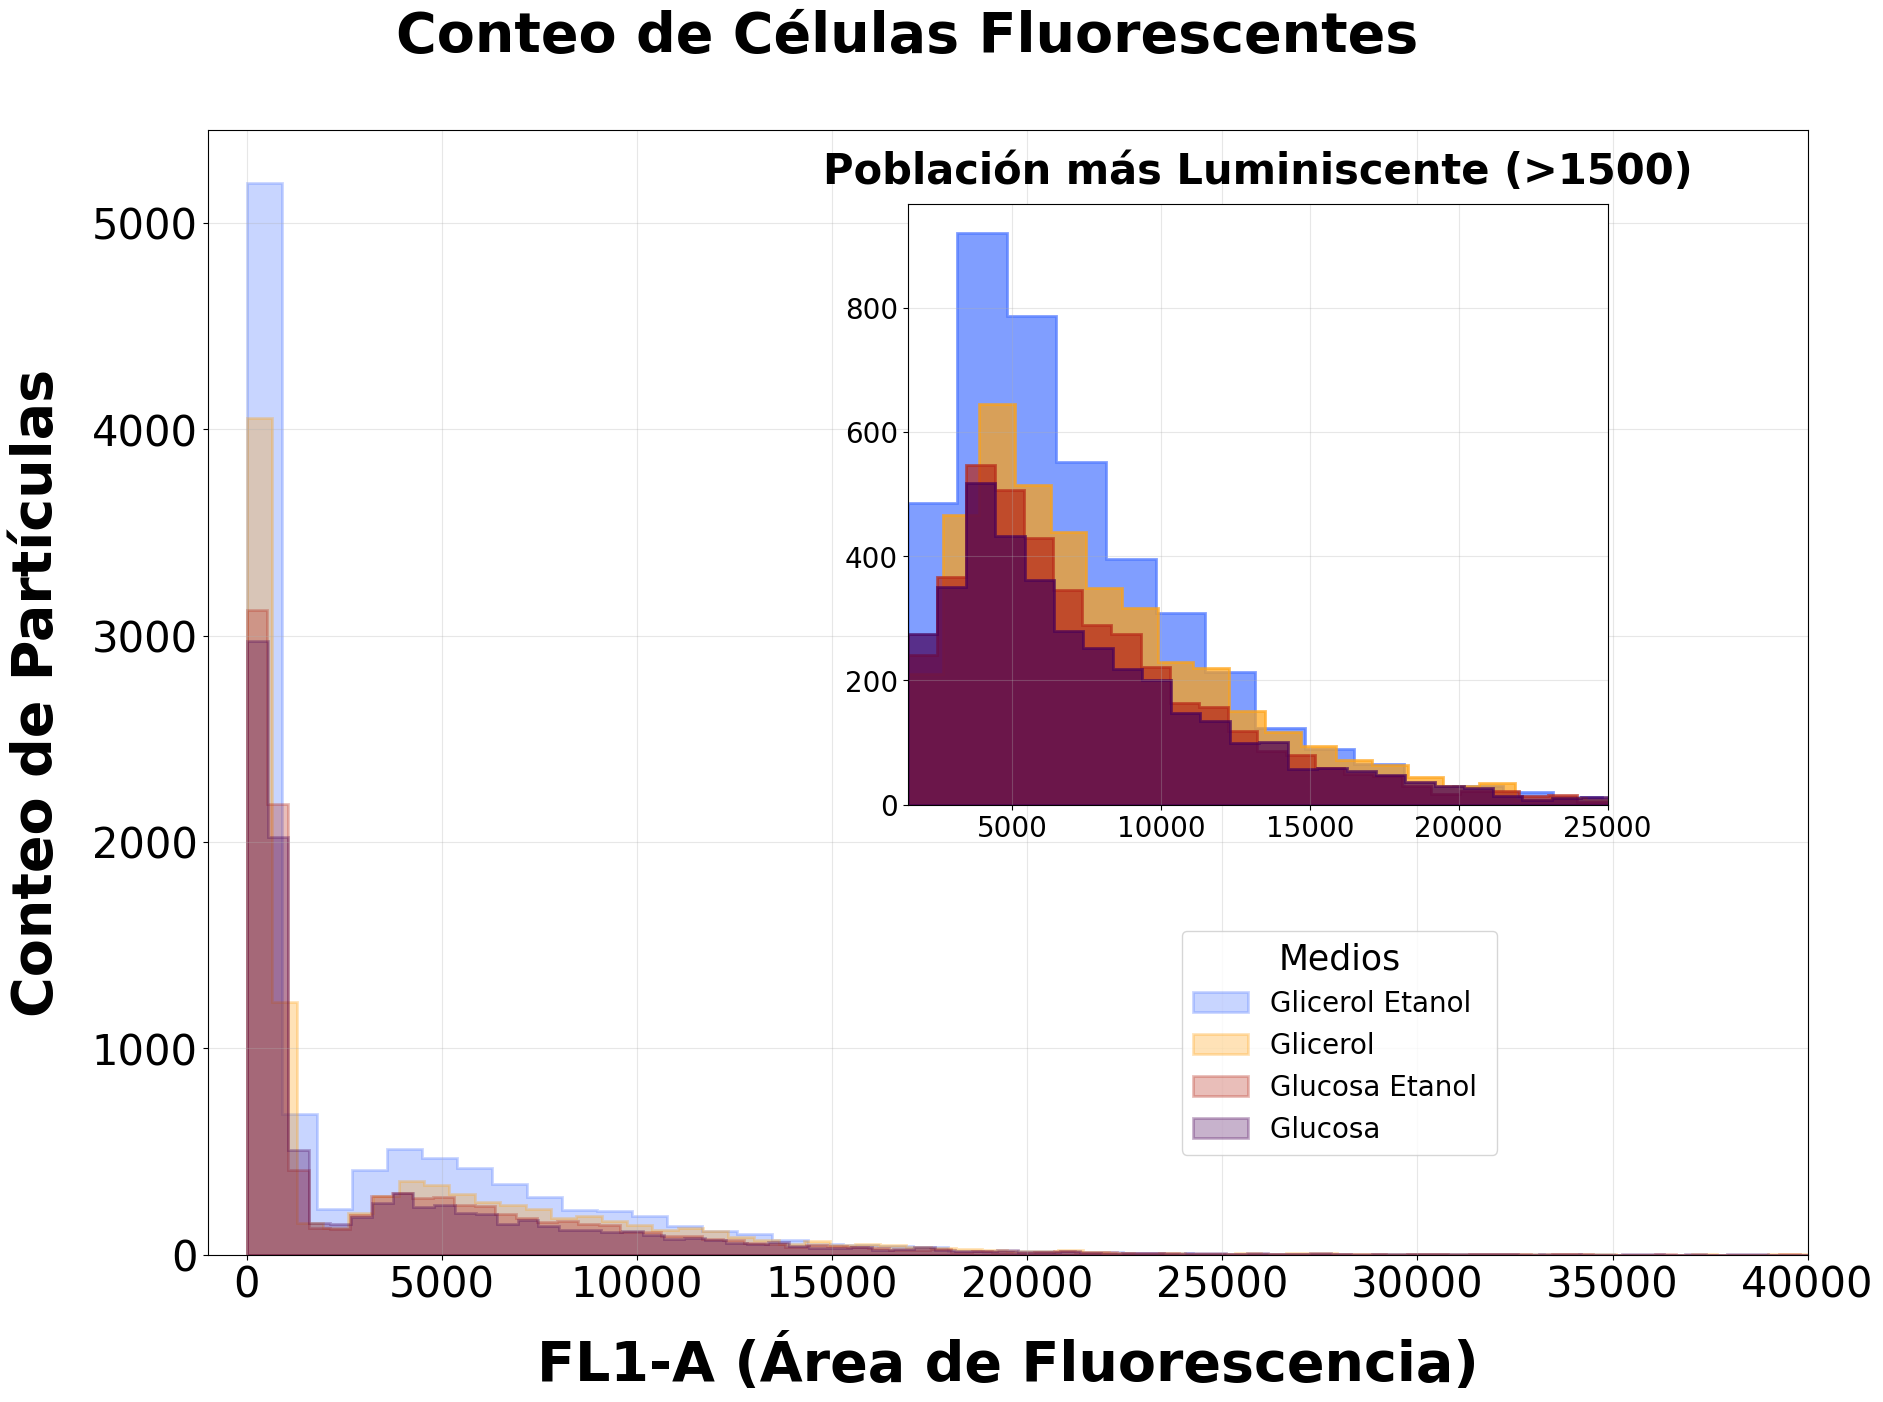

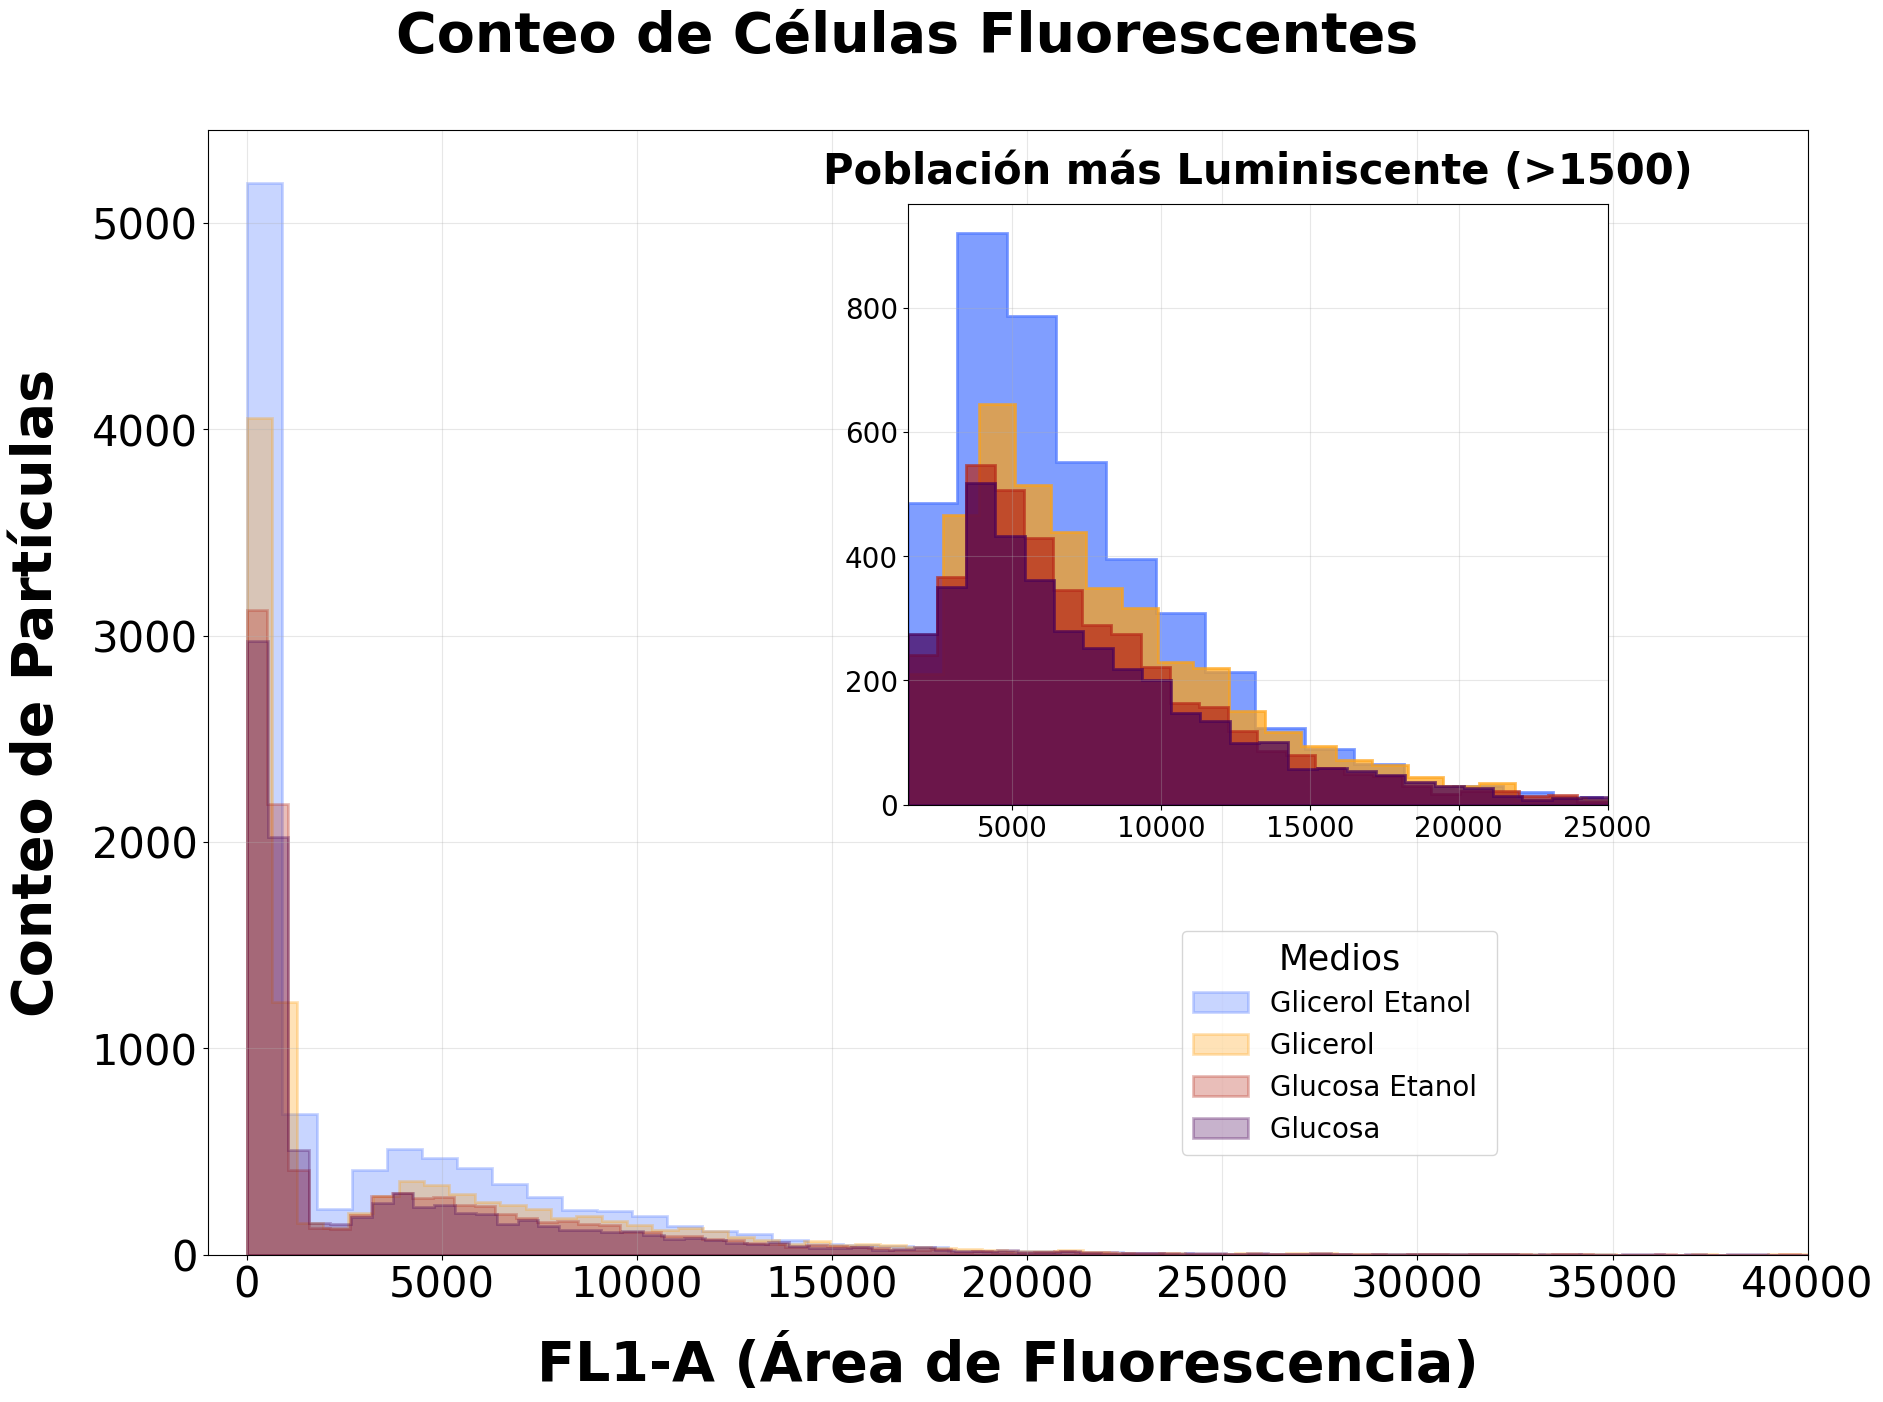

In [14]:
glicerol = cargar_datos_csv_listas('Citometro/Erol.csv')
glicerol_etanol = cargar_datos_csv_listas('Citometro/Erolol.csv')
glucosa = cargar_datos_csv_listas('Citometro/Osa.csv')
glucosa_etanol = cargar_datos_csv_listas('Citometro/Osaol.csv')


# Crear diccionario con los datos
datos_muestras = {
    
    'glicerol_etanol': (glicerol_etanol[2], glicerol_etanol[6], glicerol_etanol[1]),
    'glicerol': (glicerol[2], glicerol[6], glicerol[1]),
    'glucosa_etanol': (glucosa_etanol[2], glucosa_etanol[6], glucosa_etanol[1]),  
    'glucosa': (glucosa[2], glucosa[6], glucosa[1]),
    
}


#grafica_scatter(datos_muestras, "DatosControl")
grafica_histograma(datos_muestras, "DatosControl")

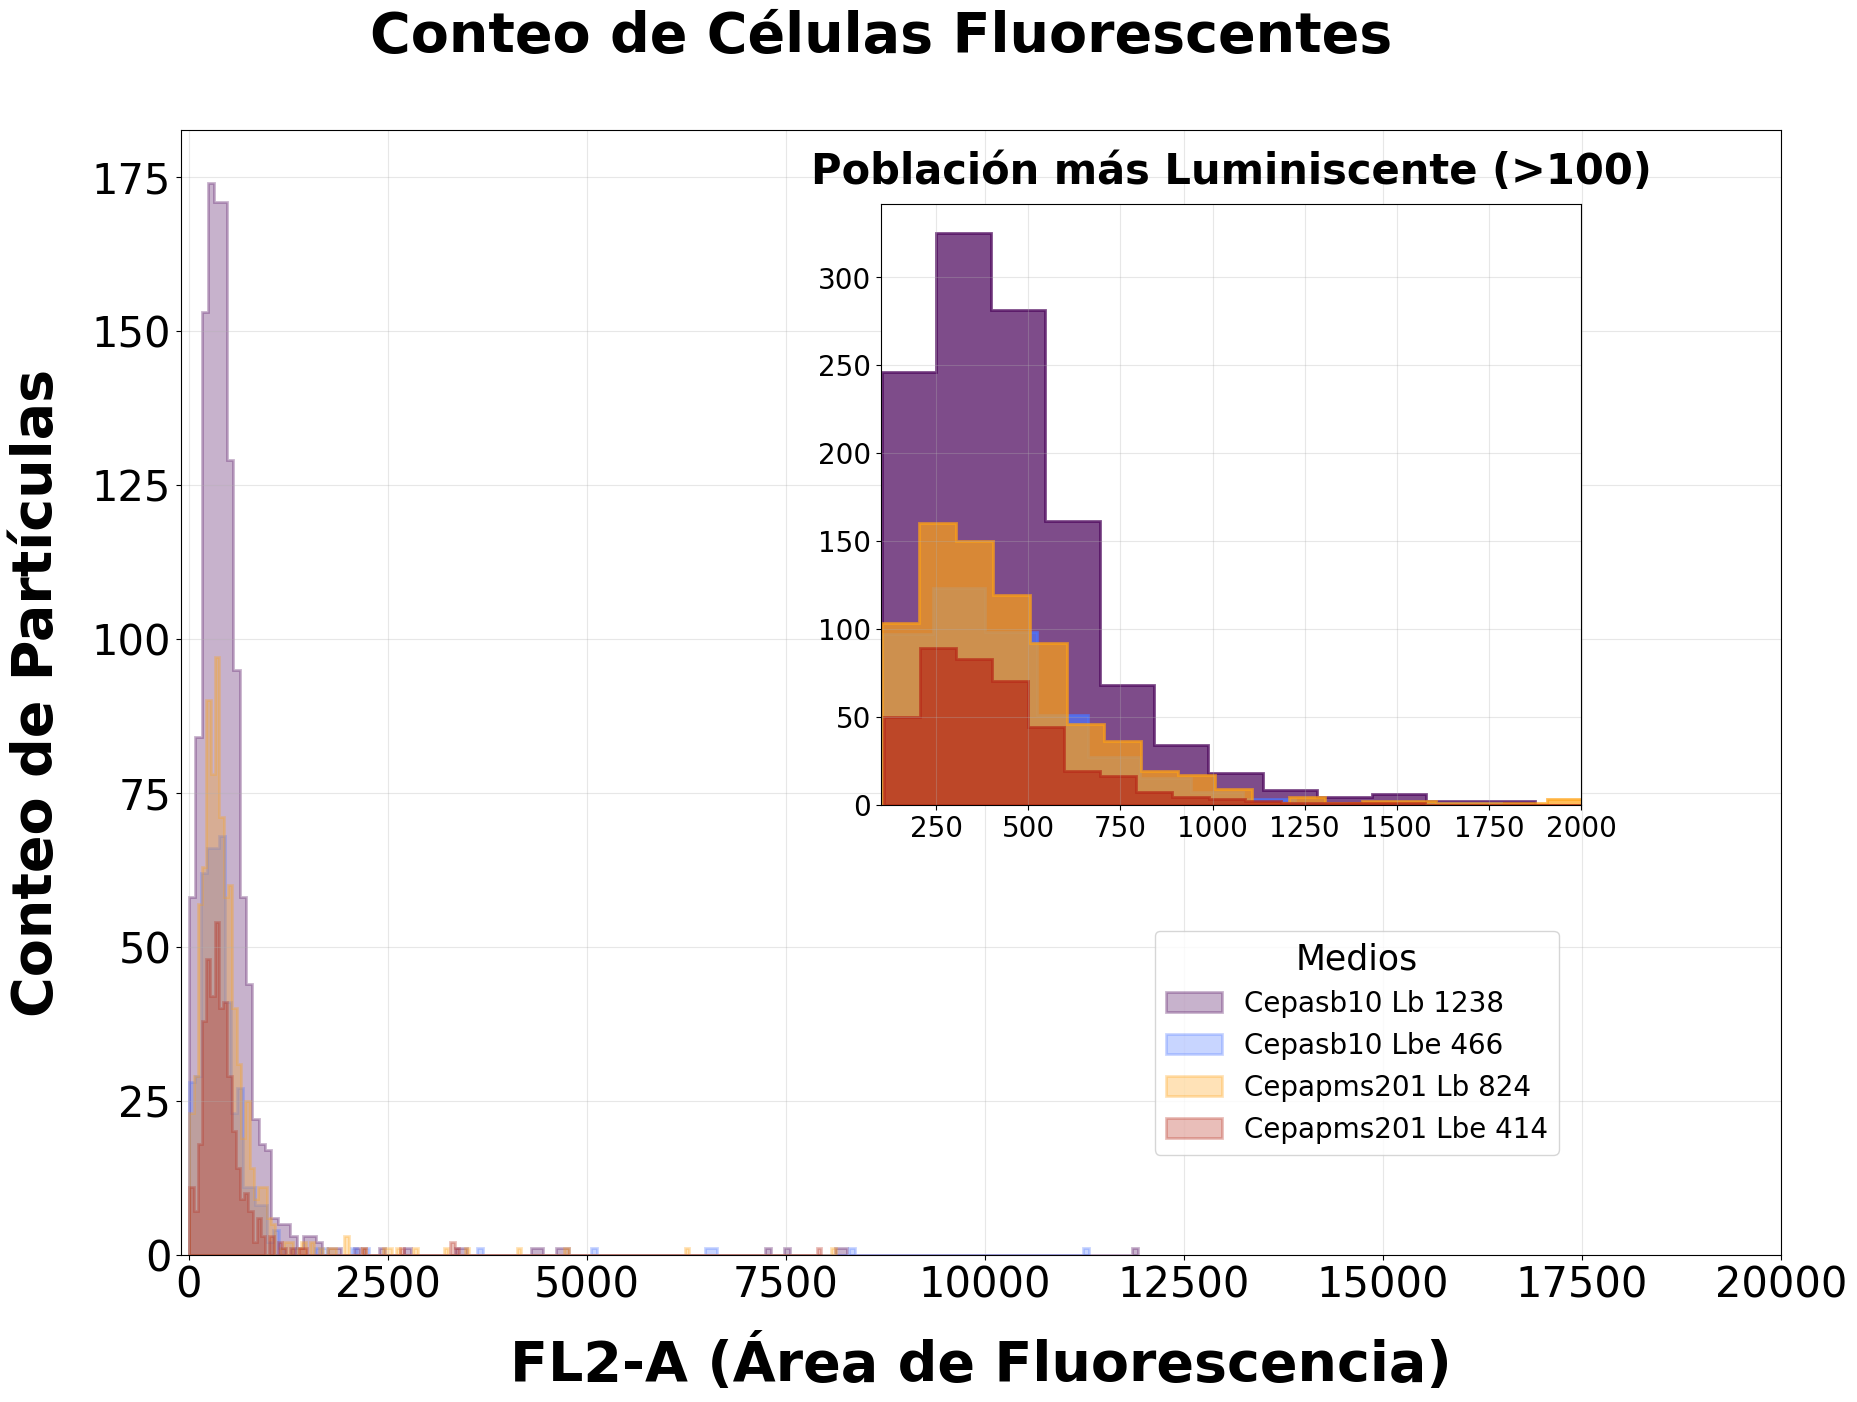

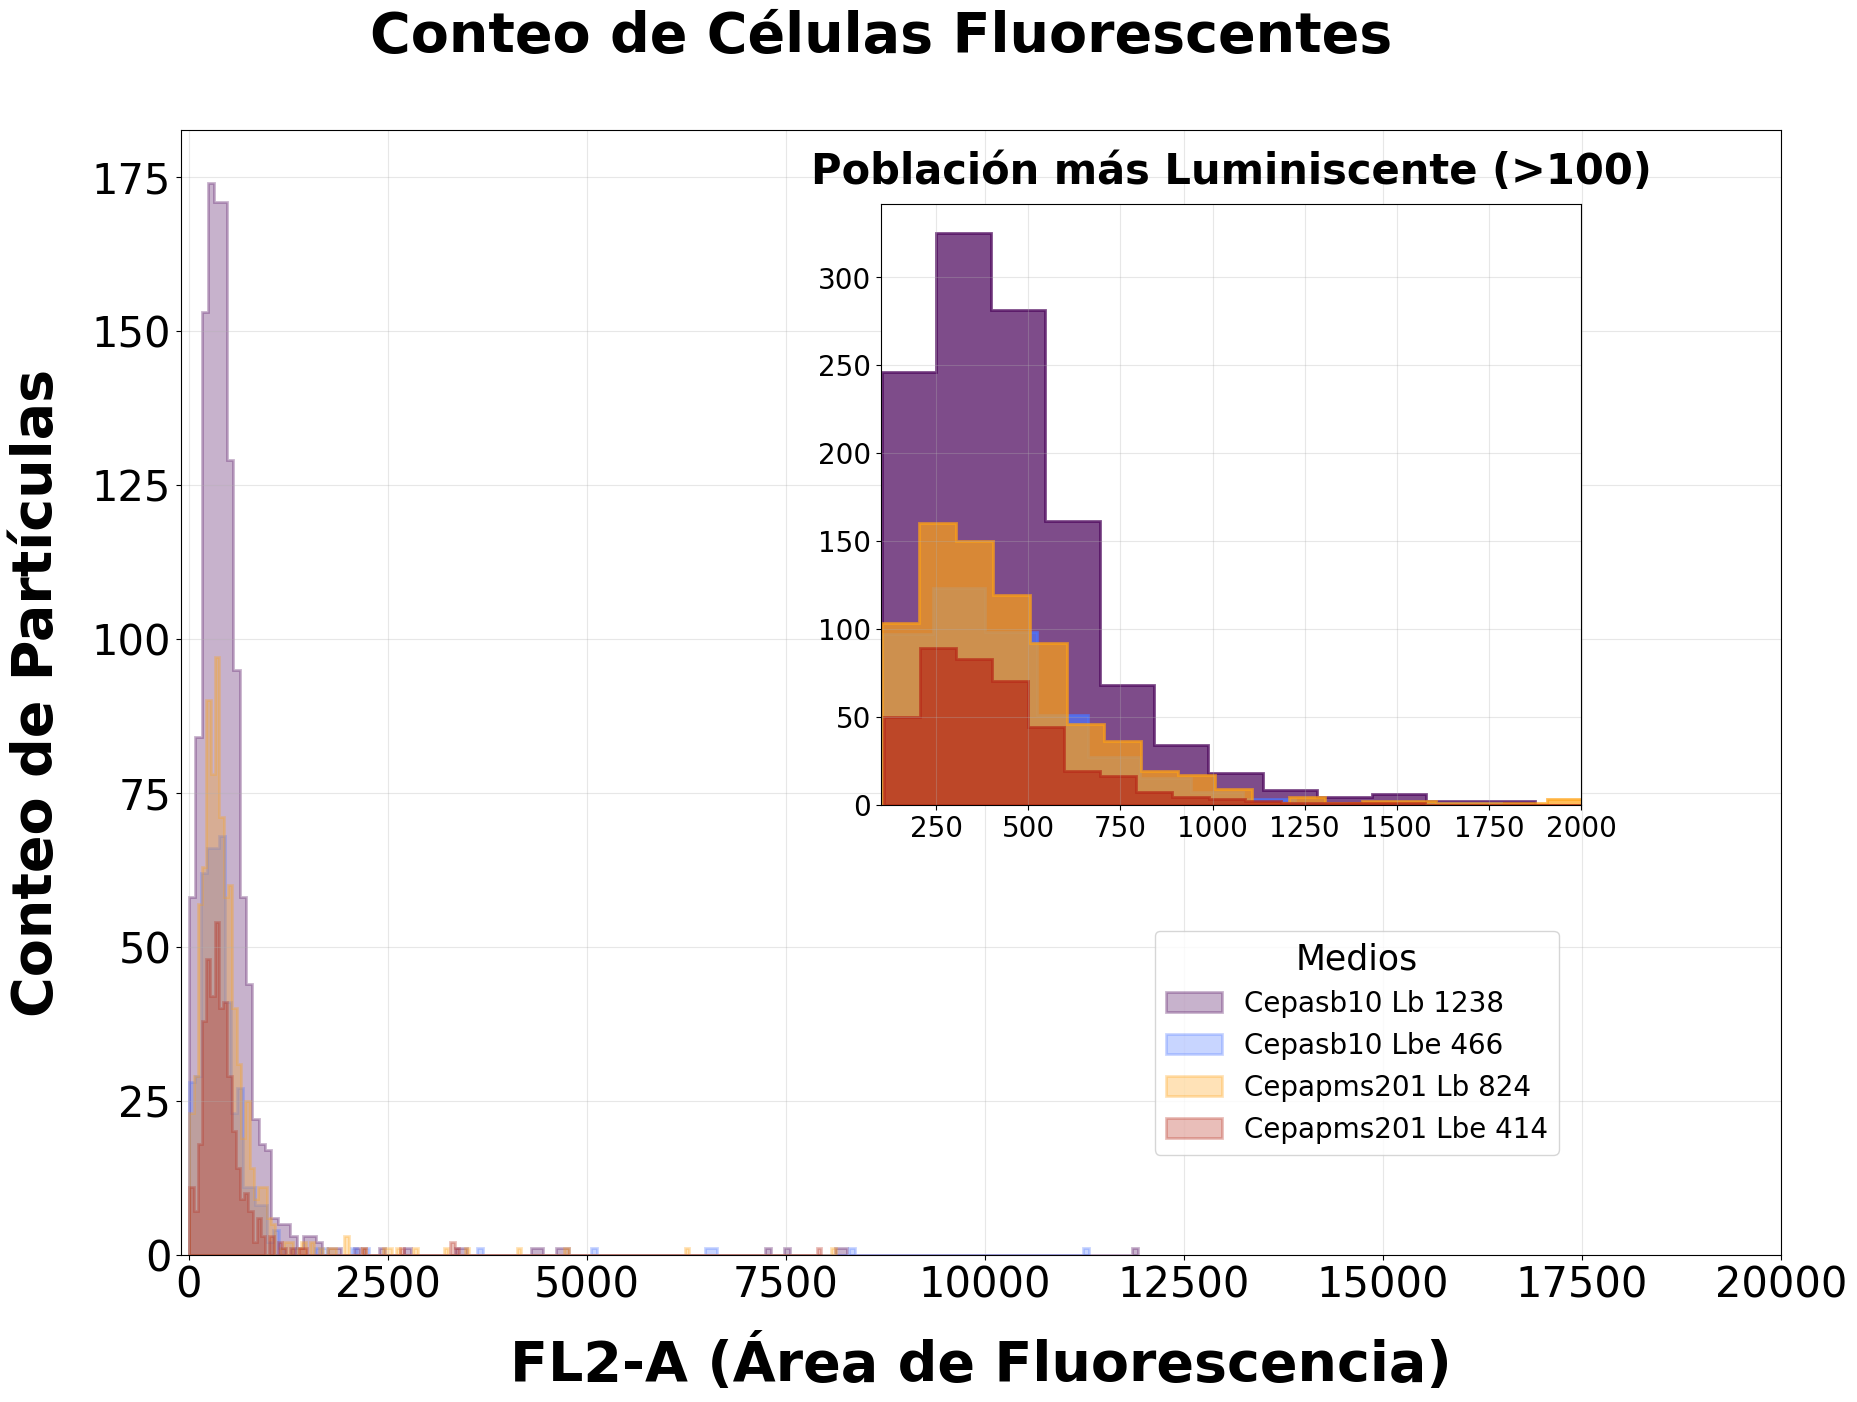

In [435]:
cepaSB10_LB_toma1 = cargar_datos_csv_listas('Citometro 2/AAA2.csv')
cepapMS201_LB_toma1 = cargar_datos_csv_listas('Citometro 2/AAA3.csv')
cepapMS201_LBE_toma1 = cargar_datos_csv_listas('Citometro 2/AAB2.csv')
cepaSB10_LBE_toma1= cargar_datos_csv_listas('Citometro 2/AAB3.csv')


# Crear diccionario con los datos
datos_muestras = {
    'cepaSB10_LB': (cepaSB10_LB_toma1[4], cepaSB10_LB_toma1[6], cepaSB10_LB_toma1[1]),
    'cepaSB10_LBE': (cepaSB10_LBE_toma1[4], cepaSB10_LBE_toma1[6], cepaSB10_LBE_toma1[1]),
    'cepapMS201_LB': (cepapMS201_LB_toma1[4], cepapMS201_LB_toma1[6], cepapMS201_LB_toma1[1]),  
    'cepapMS201_LBE': (cepapMS201_LBE_toma1[4], cepapMS201_LBE_toma1[6], cepapMS201_LBE_toma1[1]),
    
    
    
}


#grafica_scatter(datos_muestras, "DatosControl")
grafica_histograma(datos_muestras, "DatosControl")

Scatter guardado: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\DatosControl_scatter.png


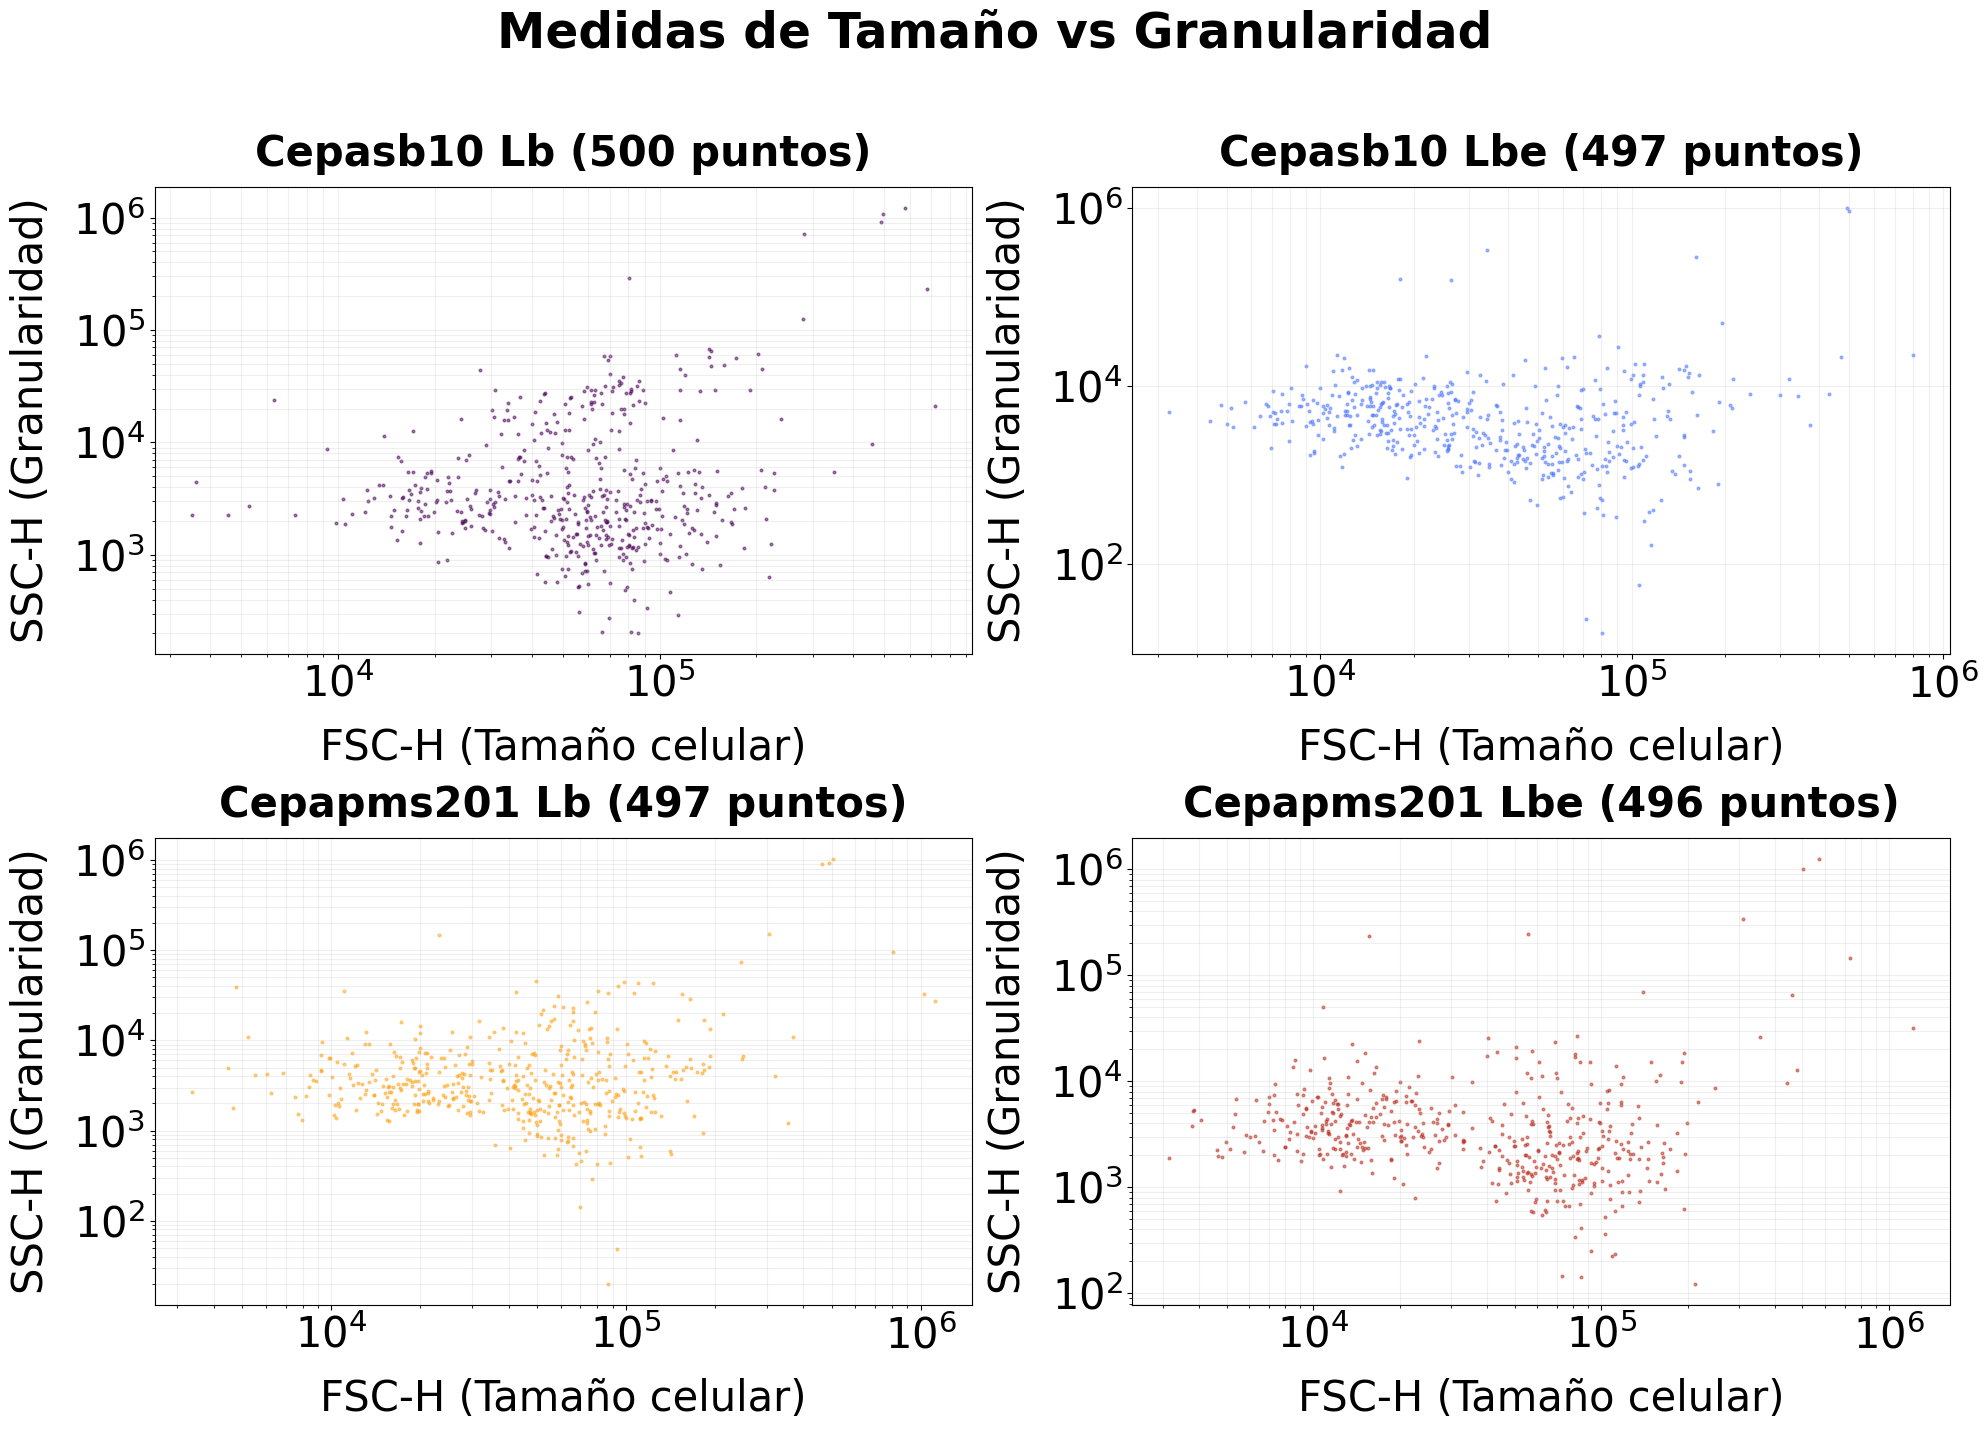

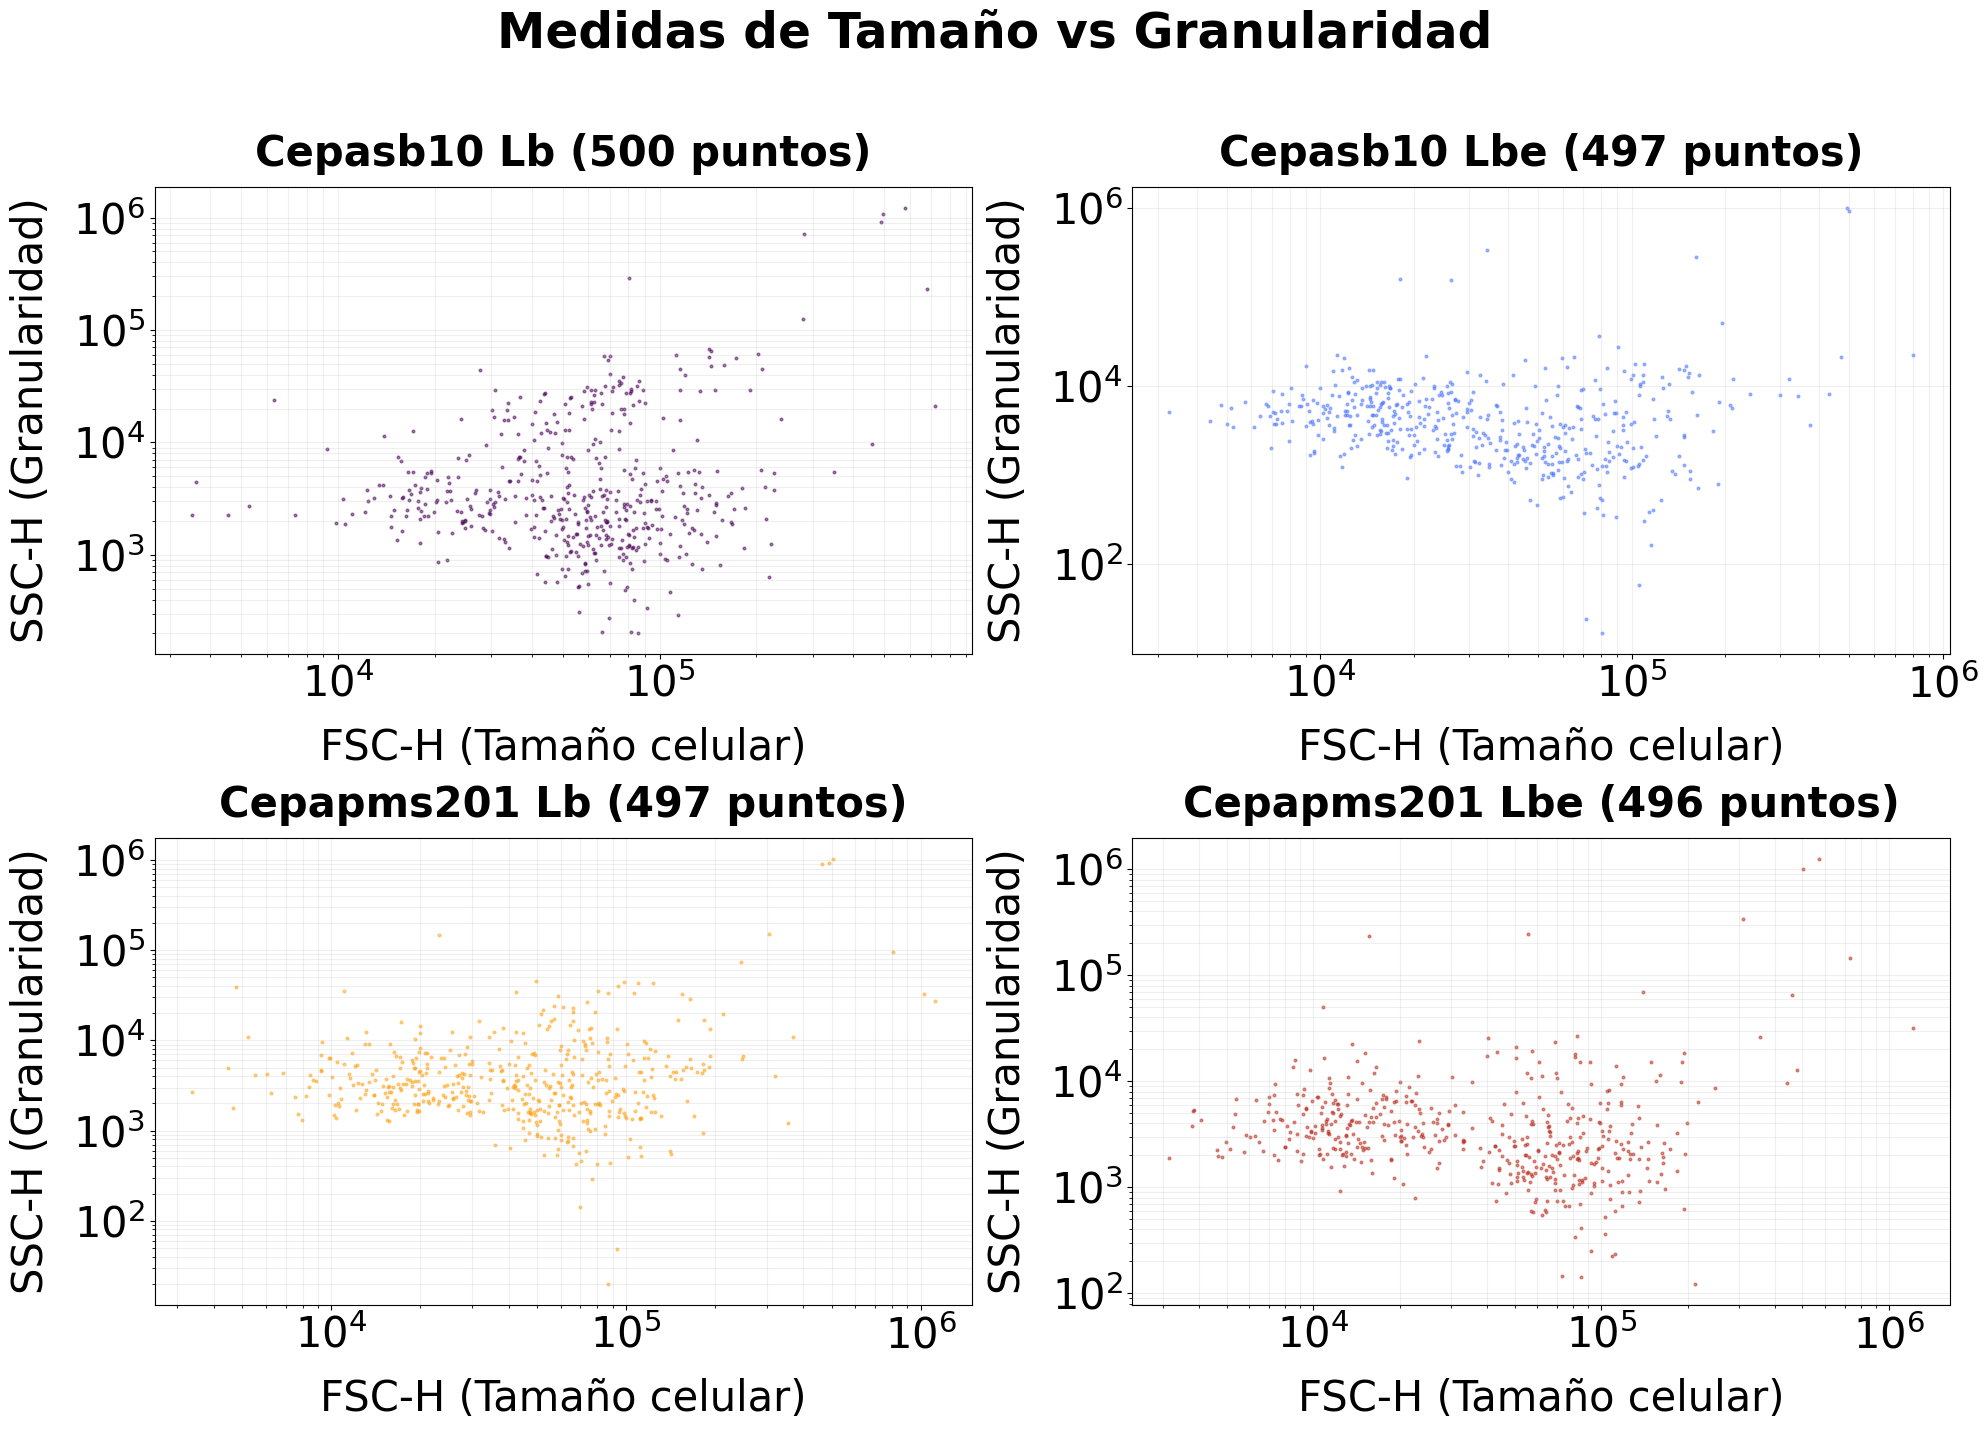

In [437]:
cepaSB10_LB_toma2 = cargar_datos_csv_listas('Citometro 2/AAC2.csv')
cepapMS201_LB_toma2 = cargar_datos_csv_listas('Citometro 2/AAC3.csv')
cepapMS201_LBE_toma2 = cargar_datos_csv_listas('Citometro 2/AAD2.csv')
cepaSB10_LBE_toma2= cargar_datos_csv_listas('Citometro 2/AAD3.csv')


# Crear diccionario con los datos
datos_muestras = {
    'cepaSB10_LB': (cepaSB10_LB_toma2[4], cepaSB10_LB_toma2[6], cepaSB10_LB_toma2[1]),
    'cepaSB10_LBE': (cepaSB10_LBE_toma2[4], cepaSB10_LBE_toma2[6], cepaSB10_LBE_toma2[1]),
    'cepapMS201_LB': (cepapMS201_LB_toma2[4], cepapMS201_LB_toma2[6], cepapMS201_LB_toma2[1]),  
    'cepapMS201_LBE': (cepapMS201_LBE_toma2[4], cepapMS201_LBE_toma2[6], cepapMS201_LBE_toma2[1]),
    
    
    
}


grafica_scatter(datos_muestras, "DatosControl")
#grafica_histograma(datos_muestras, "DatosControl")

In [18]:
#carga_de_datos
def cargar_datos_csv_listas2(ruta_archivo):
    N = [] ;     Area = [] ;    Mean = [] ;    StdDev = [];     Min = [] ;    Max = []
    
    with open(ruta_archivo, newline='') as archivo:  #
        lector = csv.reader(archivo)
        next(lector)  
        
        for fila in lector:
            N.append(int(fila[0]))
            Area.append(float(fila[1]))
            Mean.append(float(fila[2]))
            StdDev.append(float(fila[3]))
            Min.append(float(fila[4]))
            Max.append(float(fila[5]))

    return (N, Area, Mean, StdDev, Min, Max)

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize

def grafica_area_vs_tiempo(datos_dict, nombre_base, delta_t=5):
    """
    Genera dos gráficos apilados verticalmente:
      - Evolución del área promedio poblacional (puntos coloreados por N células + línea negra de tendencia).
      - Distribución de áreas (boxplots) donde el color de cada caja representa el número de células.
      Incluye barra lateral de color independiente para evitar superposiciones.
    """
    # Paleta base para construir el degradado continuo
    palette = {
        'glucosa': '#480058',
        'glicerol_etanol': '#4B75FF',
        'glicerol': '#FFA213',
        'glucosa_etanol': '#B72818'
    }
    
    colors_list = [palette['glucosa'], palette['glicerol_etanol'], 
                   palette['glicerol'], palette['glucosa_etanol']]
    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors_list, N=256)
    
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()
    save_path = os.path.join(script_dir, f"{nombre_base}_area_vs_tiempo.png")
    
    # Aumentamos ligeramente el ancho de la figura (de 16 a 19) para dar espacio a la barra
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(19, 24))
    plt.rcParams.update({'font.size': 30})
    
    todos_counts = []          
    box_data = []              
    point_data = []            
    
    # Estilos de línea para diferenciar las tendencias en negro
    estilos_linea = ['-', '--', '-.', ':']
    
    for idx_cond, (nombre, lista_tomas) in enumerate(datos_dict.items()):
        if not isinstance(lista_tomas, list):
            lista_tomas = [lista_tomas]
        
        tiempos = []
        promedios = []
        
        for idx, toma in enumerate(lista_tomas):
            if toma is None:
                continue
            t = idx * delta_t
            areas_celulas = toma[1]  
            n_cells = len(areas_celulas)
            prom = np.mean(areas_celulas)
            
            tiempos.append(t)
            promedios.append(prom)
            
            box_data.append((t, areas_celulas, n_cells, nombre))
            point_data.append((t, prom, n_cells, nombre))
            todos_counts.append(n_cells)
        
        # Dibujar línea de tendencia negra personalizada por condición
        if len(tiempos) > 1:
            estilo = estilos_linea[idx_cond % len(estilos_linea)]
            label_cond = nombre.replace('_', ' ').title()
            ax1.plot(tiempos, promedios, linestyle=estilo, color='black', 
                     linewidth=3, alpha=0.8, zorder=1, label=f"Tendencia {label_cond}")
    
    if todos_counts:
        vmin, vmax = min(todos_counts), max(todos_counts)
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=0, vmax=1)
    
    # Dibujar puntos superiores con el degradado continuo
    for (t, prom, n_cells, cond) in point_data:
        color_punto = custom_cmap(norm(n_cells))
        ax1.scatter(t, prom, s=600, color=color_punto, edgecolors='black', 
                    linewidth=2, zorder=3, alpha=0.9)
    
    # Dibujar boxplots con el degradado continuo
    for (t, areas, n_cells, cond) in box_data:
        color_box = custom_cmap(norm(n_cells))
        bp = ax2.boxplot(areas, positions=[t], widths=delta_t * 0.2,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=3),
                         flierprops=dict(marker='o', markersize=12, alpha=0.5,
                                         markeredgecolor='none', markerfacecolor='black'))
        for box in bp['boxes']:
            box.set_facecolor(color_box)
            box.set_alpha(0.8)
            box.set_edgecolor('black')
            box.set_linewidth(2)
    
    # Configuración del gráfico superior
    ax1.set_title('Evolución del Área Promedio (Degradado = N células)', fontsize=40, fontweight='bold', pad=20)
    ax1.set_xlabel('Tiempo (minutos)', fontsize=36, labelpad=10)
    ax1.set_ylabel(r'Área Promedio ($\mu$m$^2$)', fontsize=36, labelpad=10)
    ax1.tick_params(axis='both', labelsize=30)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=22, framealpha=0.9)
    
    # Configuración del gráfico inferior
    ax2.set_title('Distribución de Áreas Celulares', fontsize=40, fontweight='bold', pad=20)
    ax2.set_xlabel('Tiempo (minutos)', fontsize=36, labelpad=10)
    ax2.set_ylabel(r'Área de Células Individuales ($\mu$m$^2$)', fontsize=36, labelpad=10)
    ax2.tick_params(axis='both', labelsize=30)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Sincronizar límites de los ejes X
    tiempos_totales = [t for (t,_,_,_) in box_data]
    if tiempos_totales:
        lim_inf = min(tiempos_totales) - delta_t
        lim_sup = max(tiempos_totales) + delta_t
        ax1.set_xlim(lim_inf, lim_sup)
        ax2.set_xlim(lim_inf, lim_sup)
    
    # --- CONTROL DE DISEÑO GEOMÉTRICO (Adiós superposiciones) ---
    # Reservamos explícitamente el espacio para los plots (reducimos el ancho útil a 0.80)
    fig.subplots_adjust(left=0.12, right=0.80, top=0.93, bottom=0.07, hspace=0.45)
    
    # Creamos un eje dedicado para la barra en el espacio libre de la derecha (coordenadas de la figura)
    # [posición_izquierda, posición_inferior, ancho_barra, alto_barra]
    cax = fig.add_axes([0.85, 0.10, 0.03, 0.78])
    
    sm = ScalarMappable(norm=norm, cmap=custom_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
    cbar.set_label('Número de células por medición', fontsize=30, labelpad=25)
    cbar.ax.tick_params(labelsize=25)
    
    # Guardamos usando 'bbox_inches=tight' para asegurar que las etiquetas de la barra no se corten
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Gráfica de áreas optimizada generada exitosamente: {save_path}")
    return fig

Gráfica de áreas optimizada generada exitosamente: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\Glucosa_Tendencia_Area_area_vs_tiempo.png


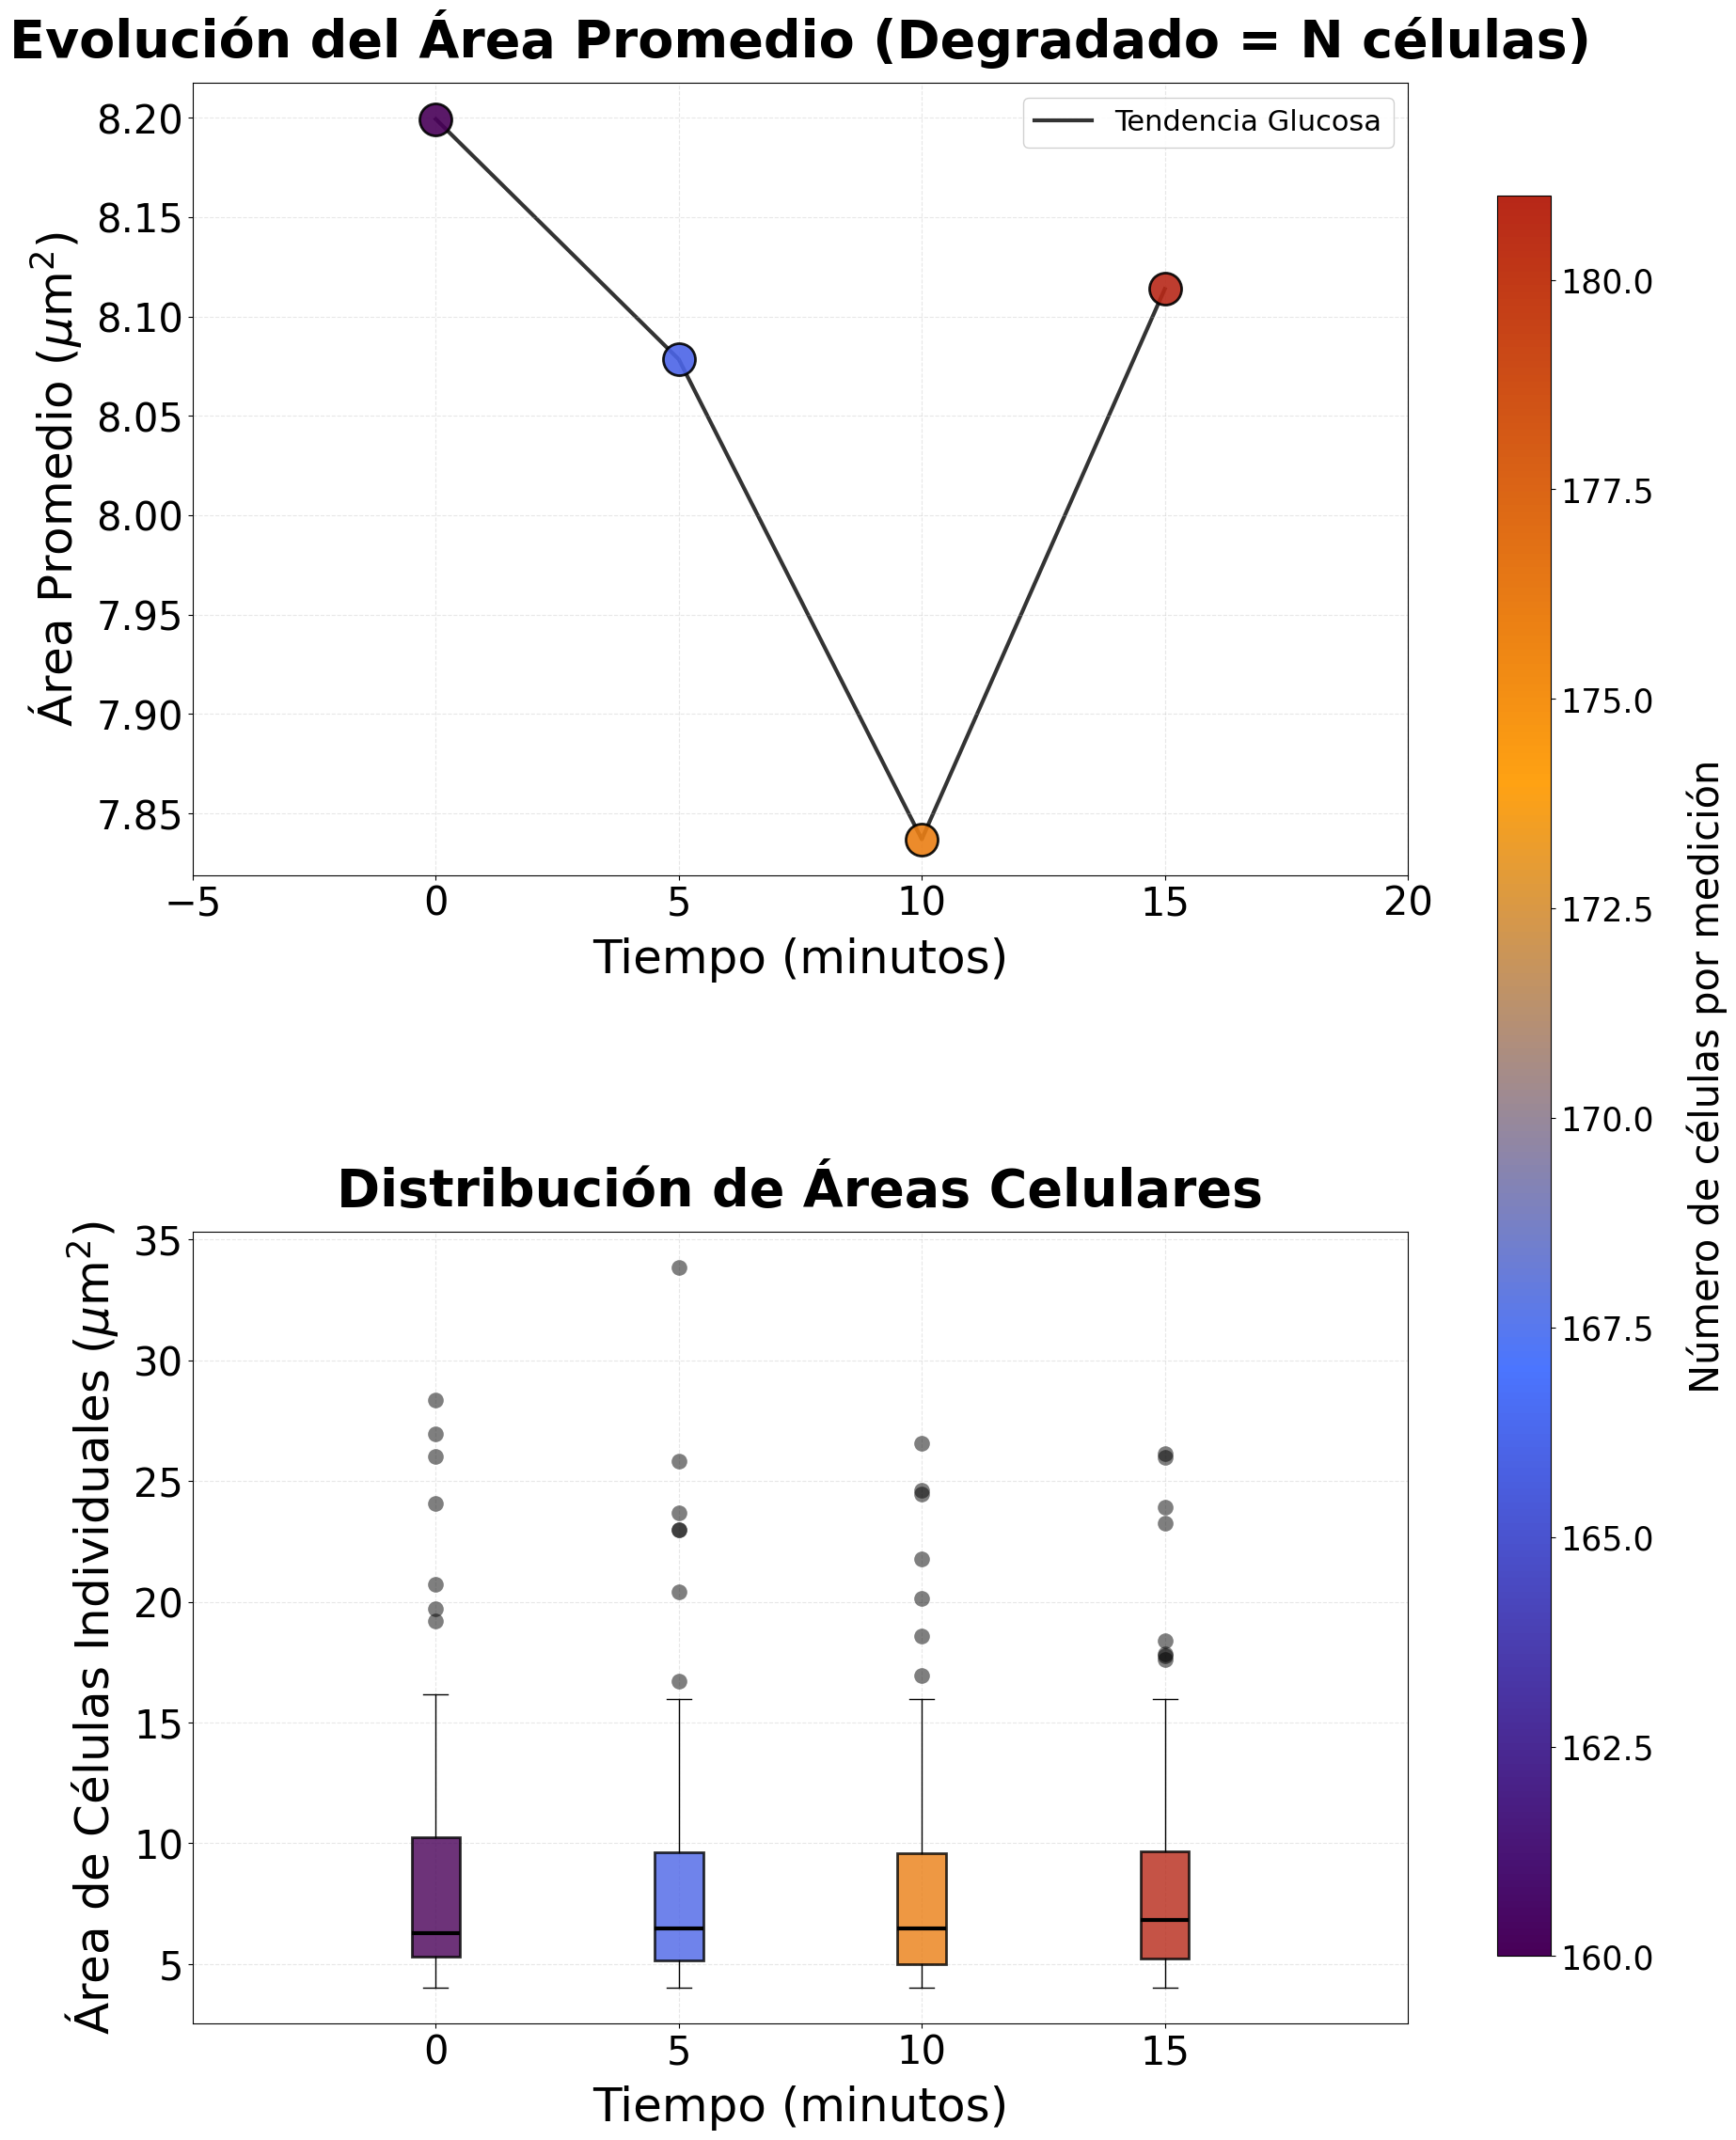

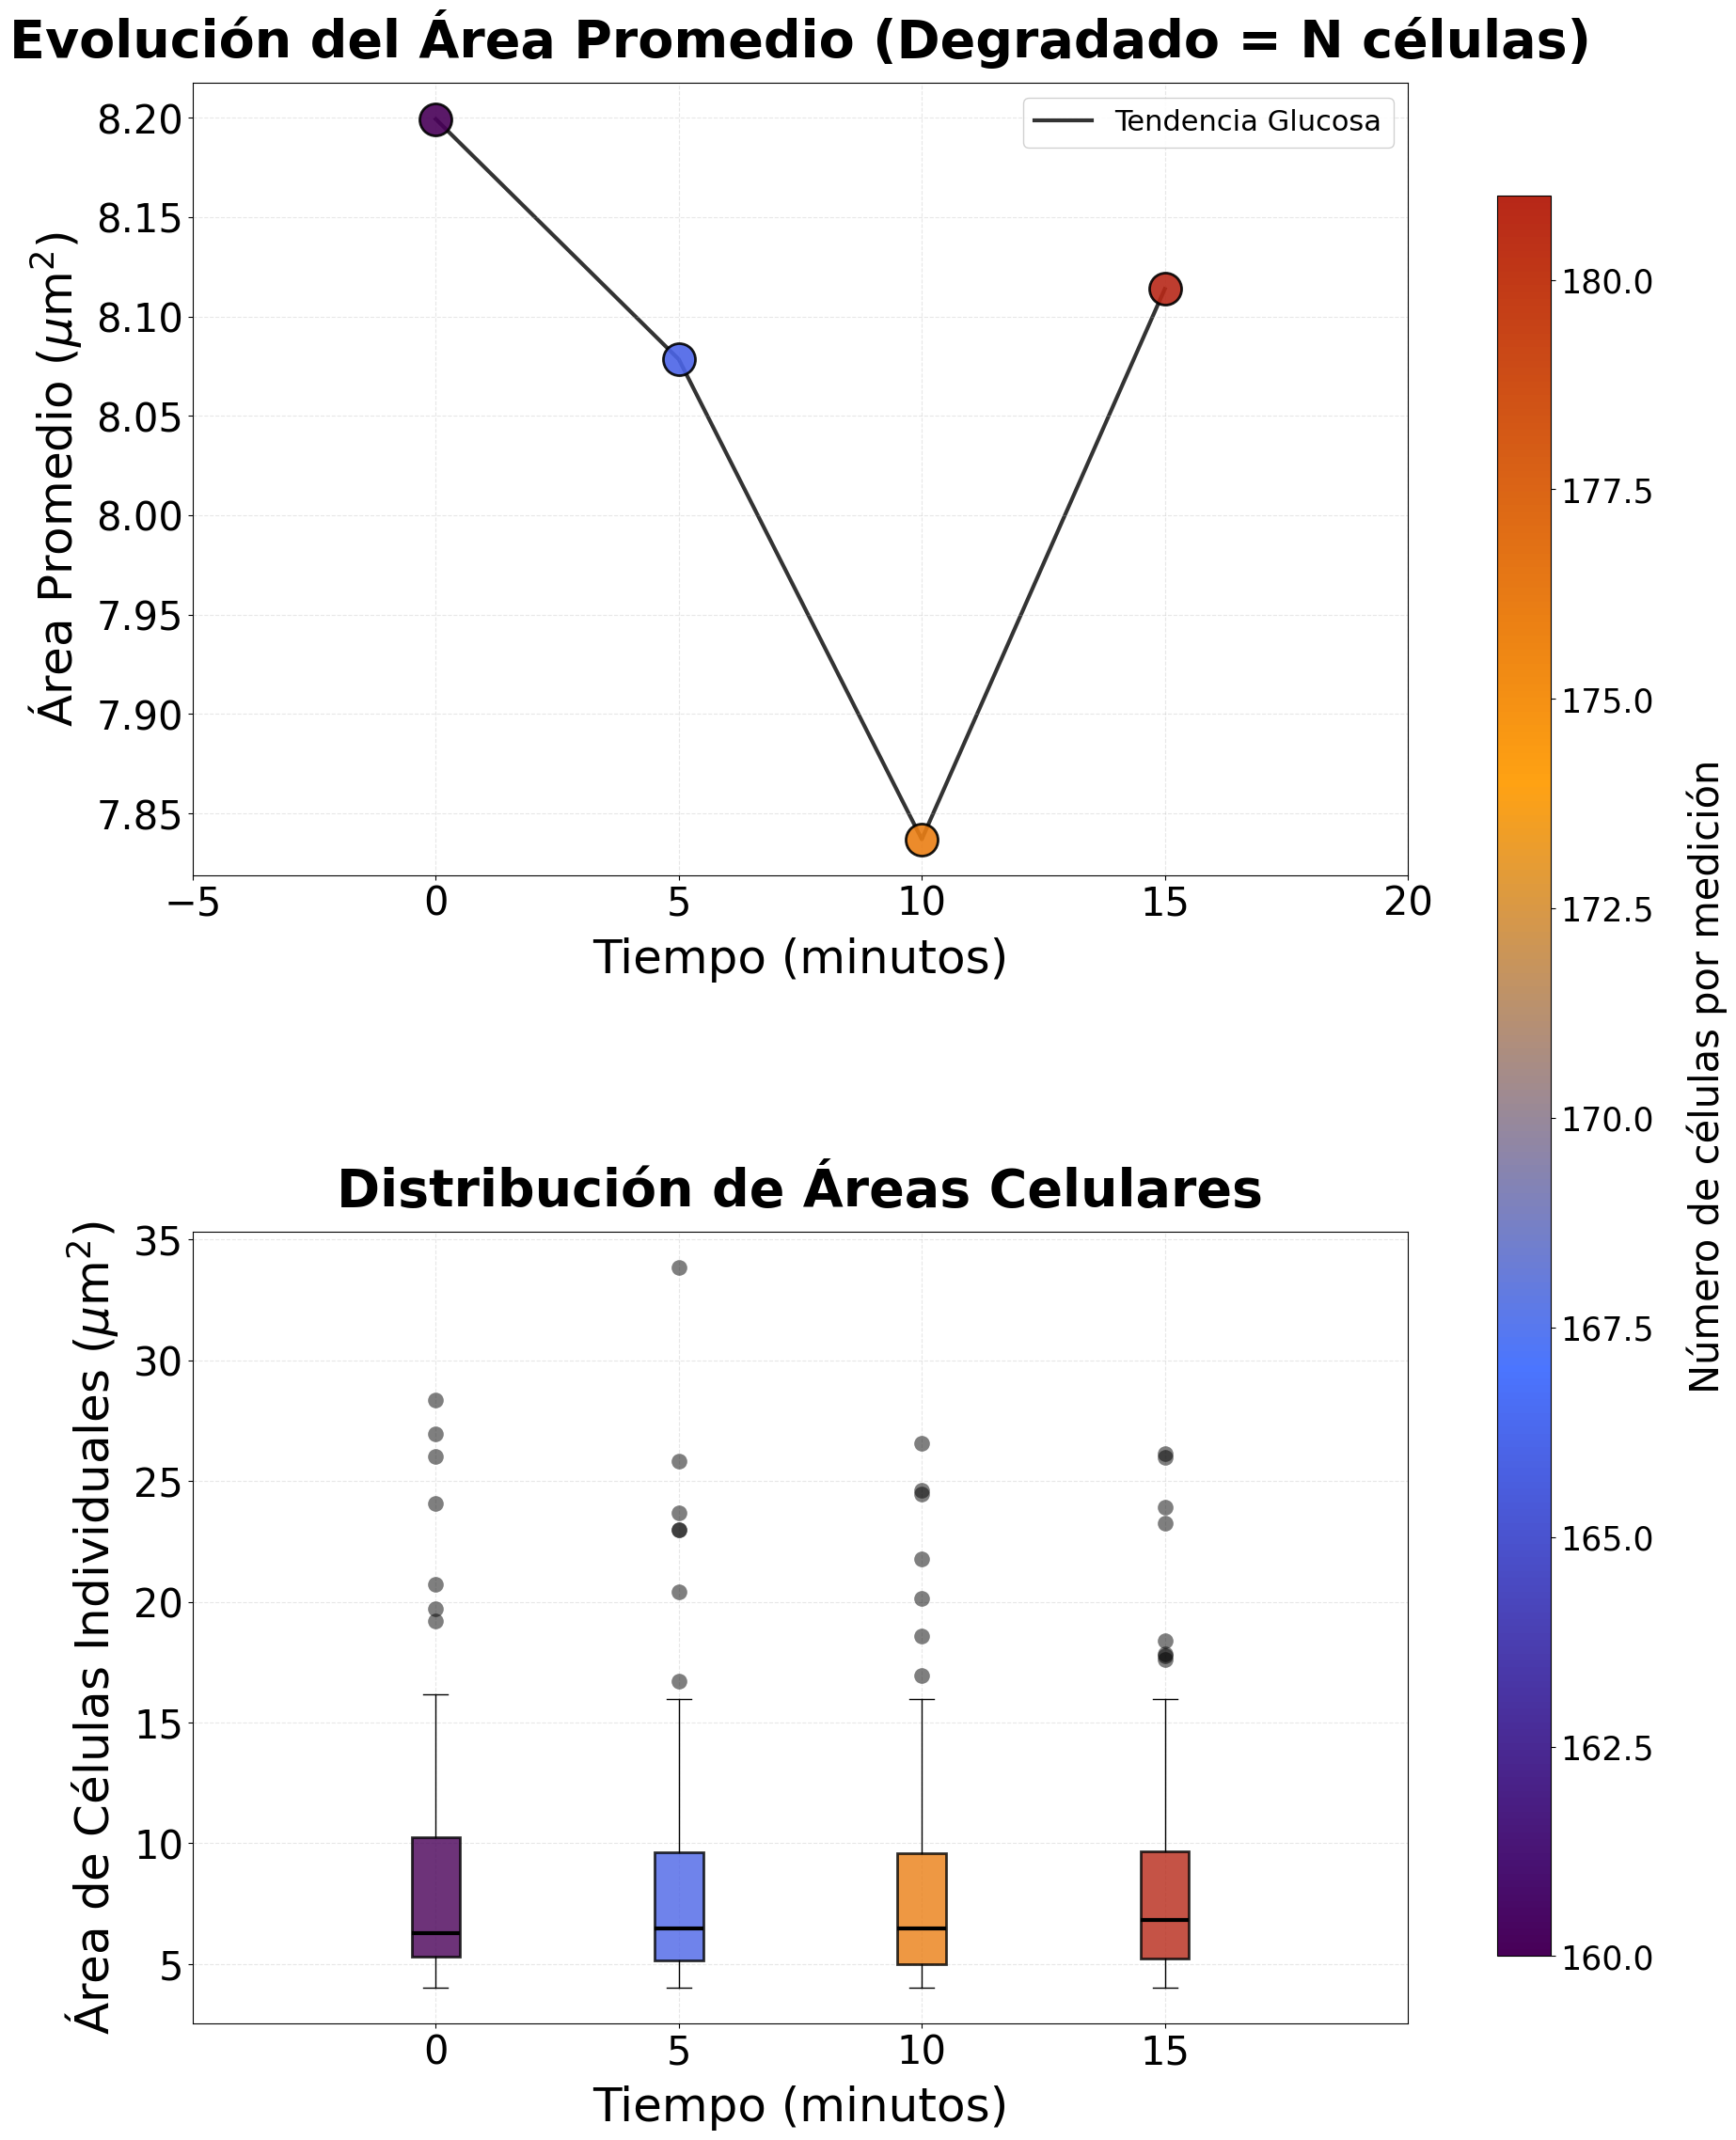

In [ ]:
toma1 = cargar_datos_csv_listas2('Microscopia/GlucosaLB1.csv')  # t = 0
toma2 = cargar_datos_csv_listas2('Microscopia/GlucosaLB2.csv')  # t = 5
toma3 = cargar_datos_csv_listas2('Microscopia/GlucosaLB3.csv')  # t = 10
toma4 = cargar_datos_csv_listas2('Microscopia/GlucosaLB4.csv')  # t = 15

# Llamada pasándole la secuencia temporal completa
grafica_area_vs_tiempo({'glucosa': [toma1, toma2, toma3, toma4]}, "Glucosa_Tendencia_Area", delta_t=5)

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize

def grafica_luminicencia_vs_tiempo(datos_dict, nombre_base, delta_t=5):
    """
    Genera dos gráficos apilados verticalmente con consistencia estilística:
      - Evolución de la luminiscencia media poblacional (puntos en degradé por N células + tendencia negra).
      - Distribución de luminiscencia (boxplots) en el tiempo con degradé uniforme.
      Incluye barra lateral de color independiente a la derecha.
    """
    # Paleta base idéntica para mantener la consistencia del degradé continuo
    palette = {
        'glucosa': '#480058',
        'glicerol_etanol': '#4B75FF',
        'glicerol': '#FFA213',
        'glucosa_etanol': '#B72818'
    }
    
    colors_list = [palette['glucosa'], palette['glicerol_etanol'], 
                   palette['glicerol'], palette['glucosa_etanol']]
    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors_list, N=256)
    
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()
    save_path = os.path.join(script_dir, f"{nombre_base}_luminicencia_vs_tiempo.png")
    
    # Dimensiones idénticas a la gráfica de área para una simetría perfecta
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(19, 24))
    plt.rcParams.update({'font.size': 30})
    
    todos_counts = []          
    box_data = []              
    point_data = []            
    
    estilos_linea = ['-', '--', '-.', ':']
    
    # Primer pase: Recolección de datos y graficación de líneas de tendencia
    for idx_cond, (nombre, lista_tomas) in enumerate(datos_dict.items()):
        if not isinstance(lista_tomas, list):
            lista_tomas = [lista_tomas]
        
        tiempos = []
        promedios_lum = []
        
        for idx, toma in enumerate(lista_tomas):
            if toma is None:
                continue
            t = idx * delta_t
            
            # El índice 2 contiene la luminiscencia por célula
            lum_celulas = toma[2]  
            n_cells = len(lum_celulas)
            prom = np.mean(lum_celulas)
            
            tiempos.append(t)
            promedios_lum.append(prom)
            
            box_data.append((t, lum_celulas, n_cells, nombre))
            point_data.append((t, prom, n_cells, nombre))
            todos_counts.append(n_cells)
        
        # Dibujar línea de tendencia negra por condición
        if len(tiempos) > 1:
            estilo = estilos_linea[idx_cond % len(estilos_linea)]
            label_cond = nombre.replace('_', ' ').title()
            ax1.plot(tiempos, promedios_lum, linestyle=estilo, color='black', 
                     linewidth=3, alpha=0.8, zorder=1, label=f"Tendencia {label_cond}")
    
    if todos_counts:
        vmin, vmax = min(todos_counts), max(todos_counts)
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=0, vmax=1)
    
    # --- Dibujar puntos superiores (Luminiscencia Promedio en degradé) ---
    for (t, prom, n_cells, cond) in point_data:
        color_punto = custom_cmap(norm(n_cells))
        ax1.scatter(t, prom, s=600, color=color_punto, edgecolors='black', 
                    linewidth=2, zorder=3, alpha=0.9)
    
    # --- Dibujar boxplots inferiores (Distribución en degradé) ---
    for (t, lum_celulas, n_cells, cond) in box_data:
        color_box = custom_cmap(norm(n_cells))
        bp = ax2.boxplot(lum_celulas, positions=[t], widths=delta_t * 0.2,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=3),
                         flierprops=dict(marker='o', markersize=12, alpha=0.5,
                                         markeredgecolor='none', markerfacecolor='black'))
        for box in bp['boxes']:
            box.set_facecolor(color_box)
            box.set_alpha(0.8)
            box.set_edgecolor('black')
            box.set_linewidth(2)
    
    # --- Estética del gráfico superior ---
    ax1.set_title('Evolución de la Luminiscencia Promedio', fontsize=40, fontweight='bold', pad=20)
    ax1.set_xlabel('Tiempo (minutos)', fontsize=36, labelpad=10)
    ax1.set_ylabel('Luminiscencia Promedio (U.A.)', fontsize=36, labelpad=10)
    ax1.tick_params(axis='both', labelsize=30)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=22, framealpha=0.9)
    
    # --- Estética del gráfico inferior ---
    ax2.set_title('Distribución de Luminiscencia Celular ', fontsize=40, fontweight='bold', pad=20)
    ax2.set_xlabel('Tiempo (minutos)', fontsize=36, labelpad=10)
    ax2.set_ylabel('Luminiscencia de Células Individuales (U.A.)', fontsize=36, labelpad=10)
    ax2.tick_params(axis='both', labelsize=30)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Sincronizar límites de los ejes X
    tiempos_totales = [t for (t,_,_,_) in box_data]
    if tiempos_totales:
        lim_inf = min(tiempos_totales) - delta_t
        lim_sup = max(tiempos_totales) + delta_t
        ax1.set_xlim(lim_inf, lim_sup)
        ax2.set_xlim(lim_inf, lim_sup)
    
    # --- GEOMETRÍA DE DISEÑO DE ALTA PRECISIÓN (Evita solapamientos) ---
    # Ajuste manual idéntico para que las cajas de los gráficos midan exactamente lo mismo
    fig.subplots_adjust(left=0.12, right=0.80, top=0.93, bottom=0.07, hspace=0.45)
    
    # Eje independiente para la barra de color (mismas coordenadas exactas)
    cax = fig.add_axes([0.85, 0.10, 0.03, 0.78])
    
    sm = ScalarMappable(norm=norm, cmap=custom_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
    cbar.set_label('Número de células por medición', fontsize=30, labelpad=25)
    cbar.ax.tick_params(labelsize=25)
    
    # Guardar con ajuste estricto de recuadro
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Gráfica de luminiscencia optimizada generada exitosamente: {save_path}")
    return fig

Gráfica de luminiscencia optimizada generada exitosamente: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\Glucosa_Tendencia_Area_luminicencia_vs_tiempo.png


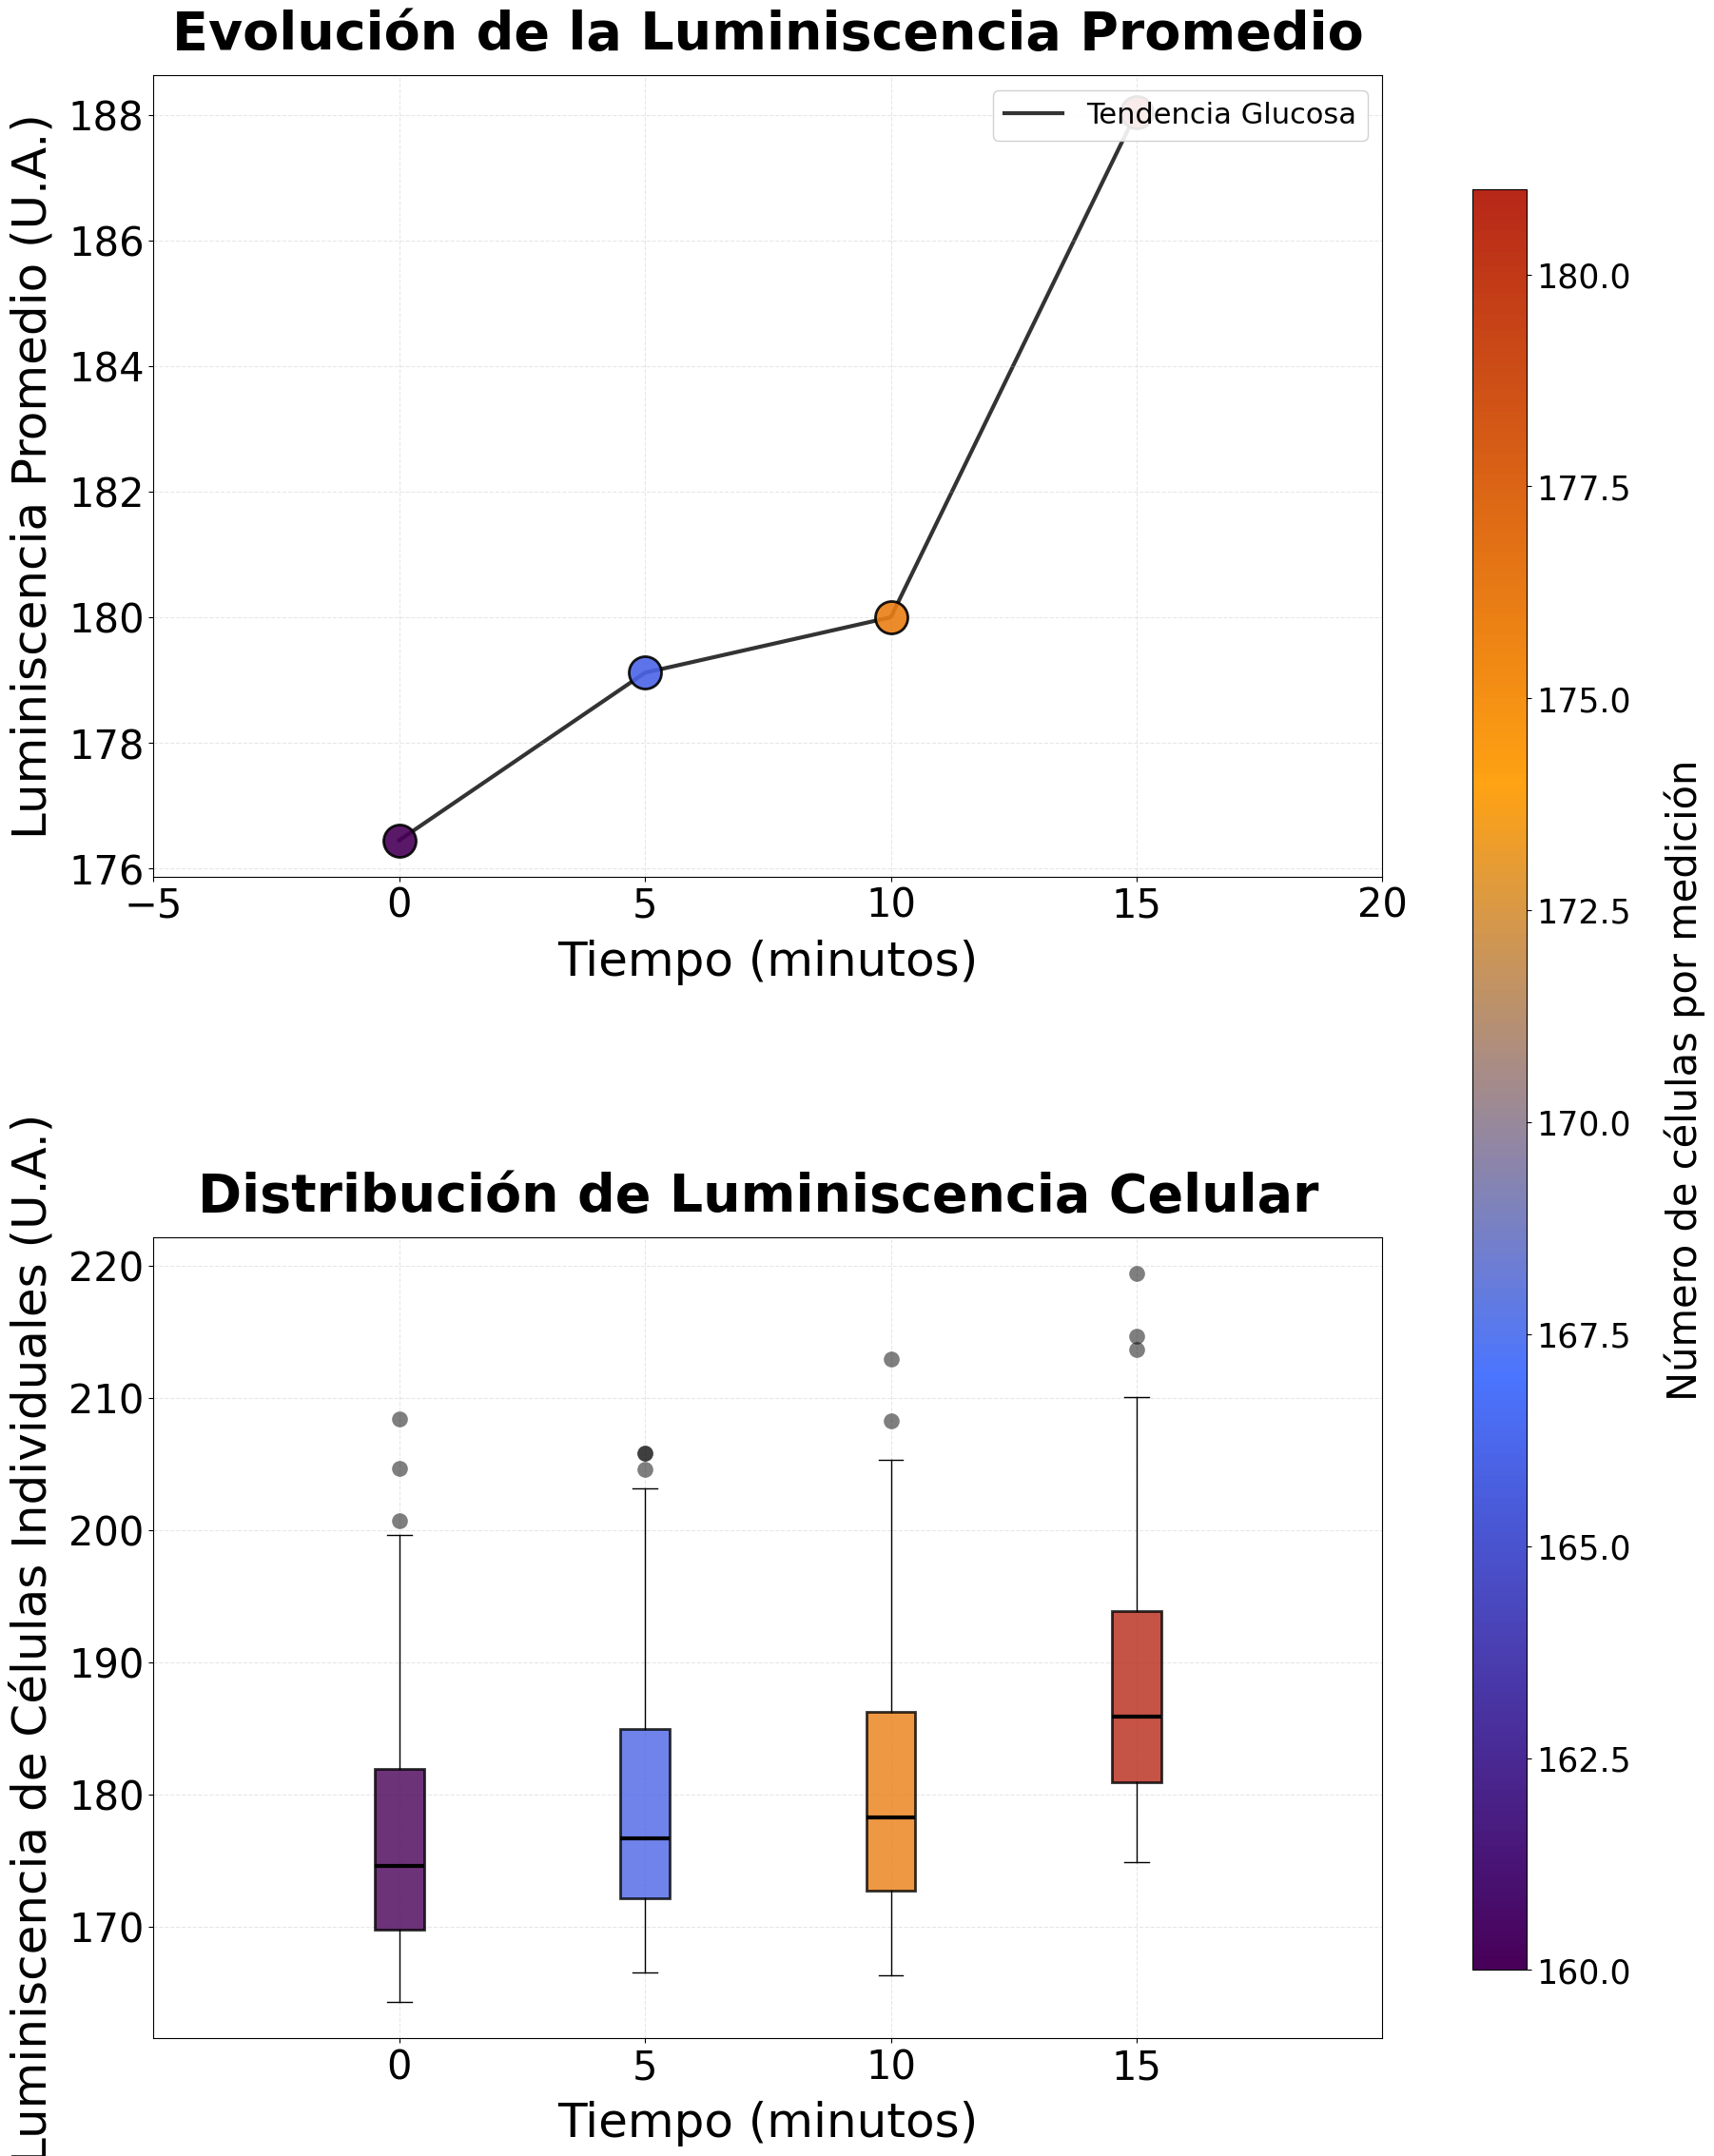

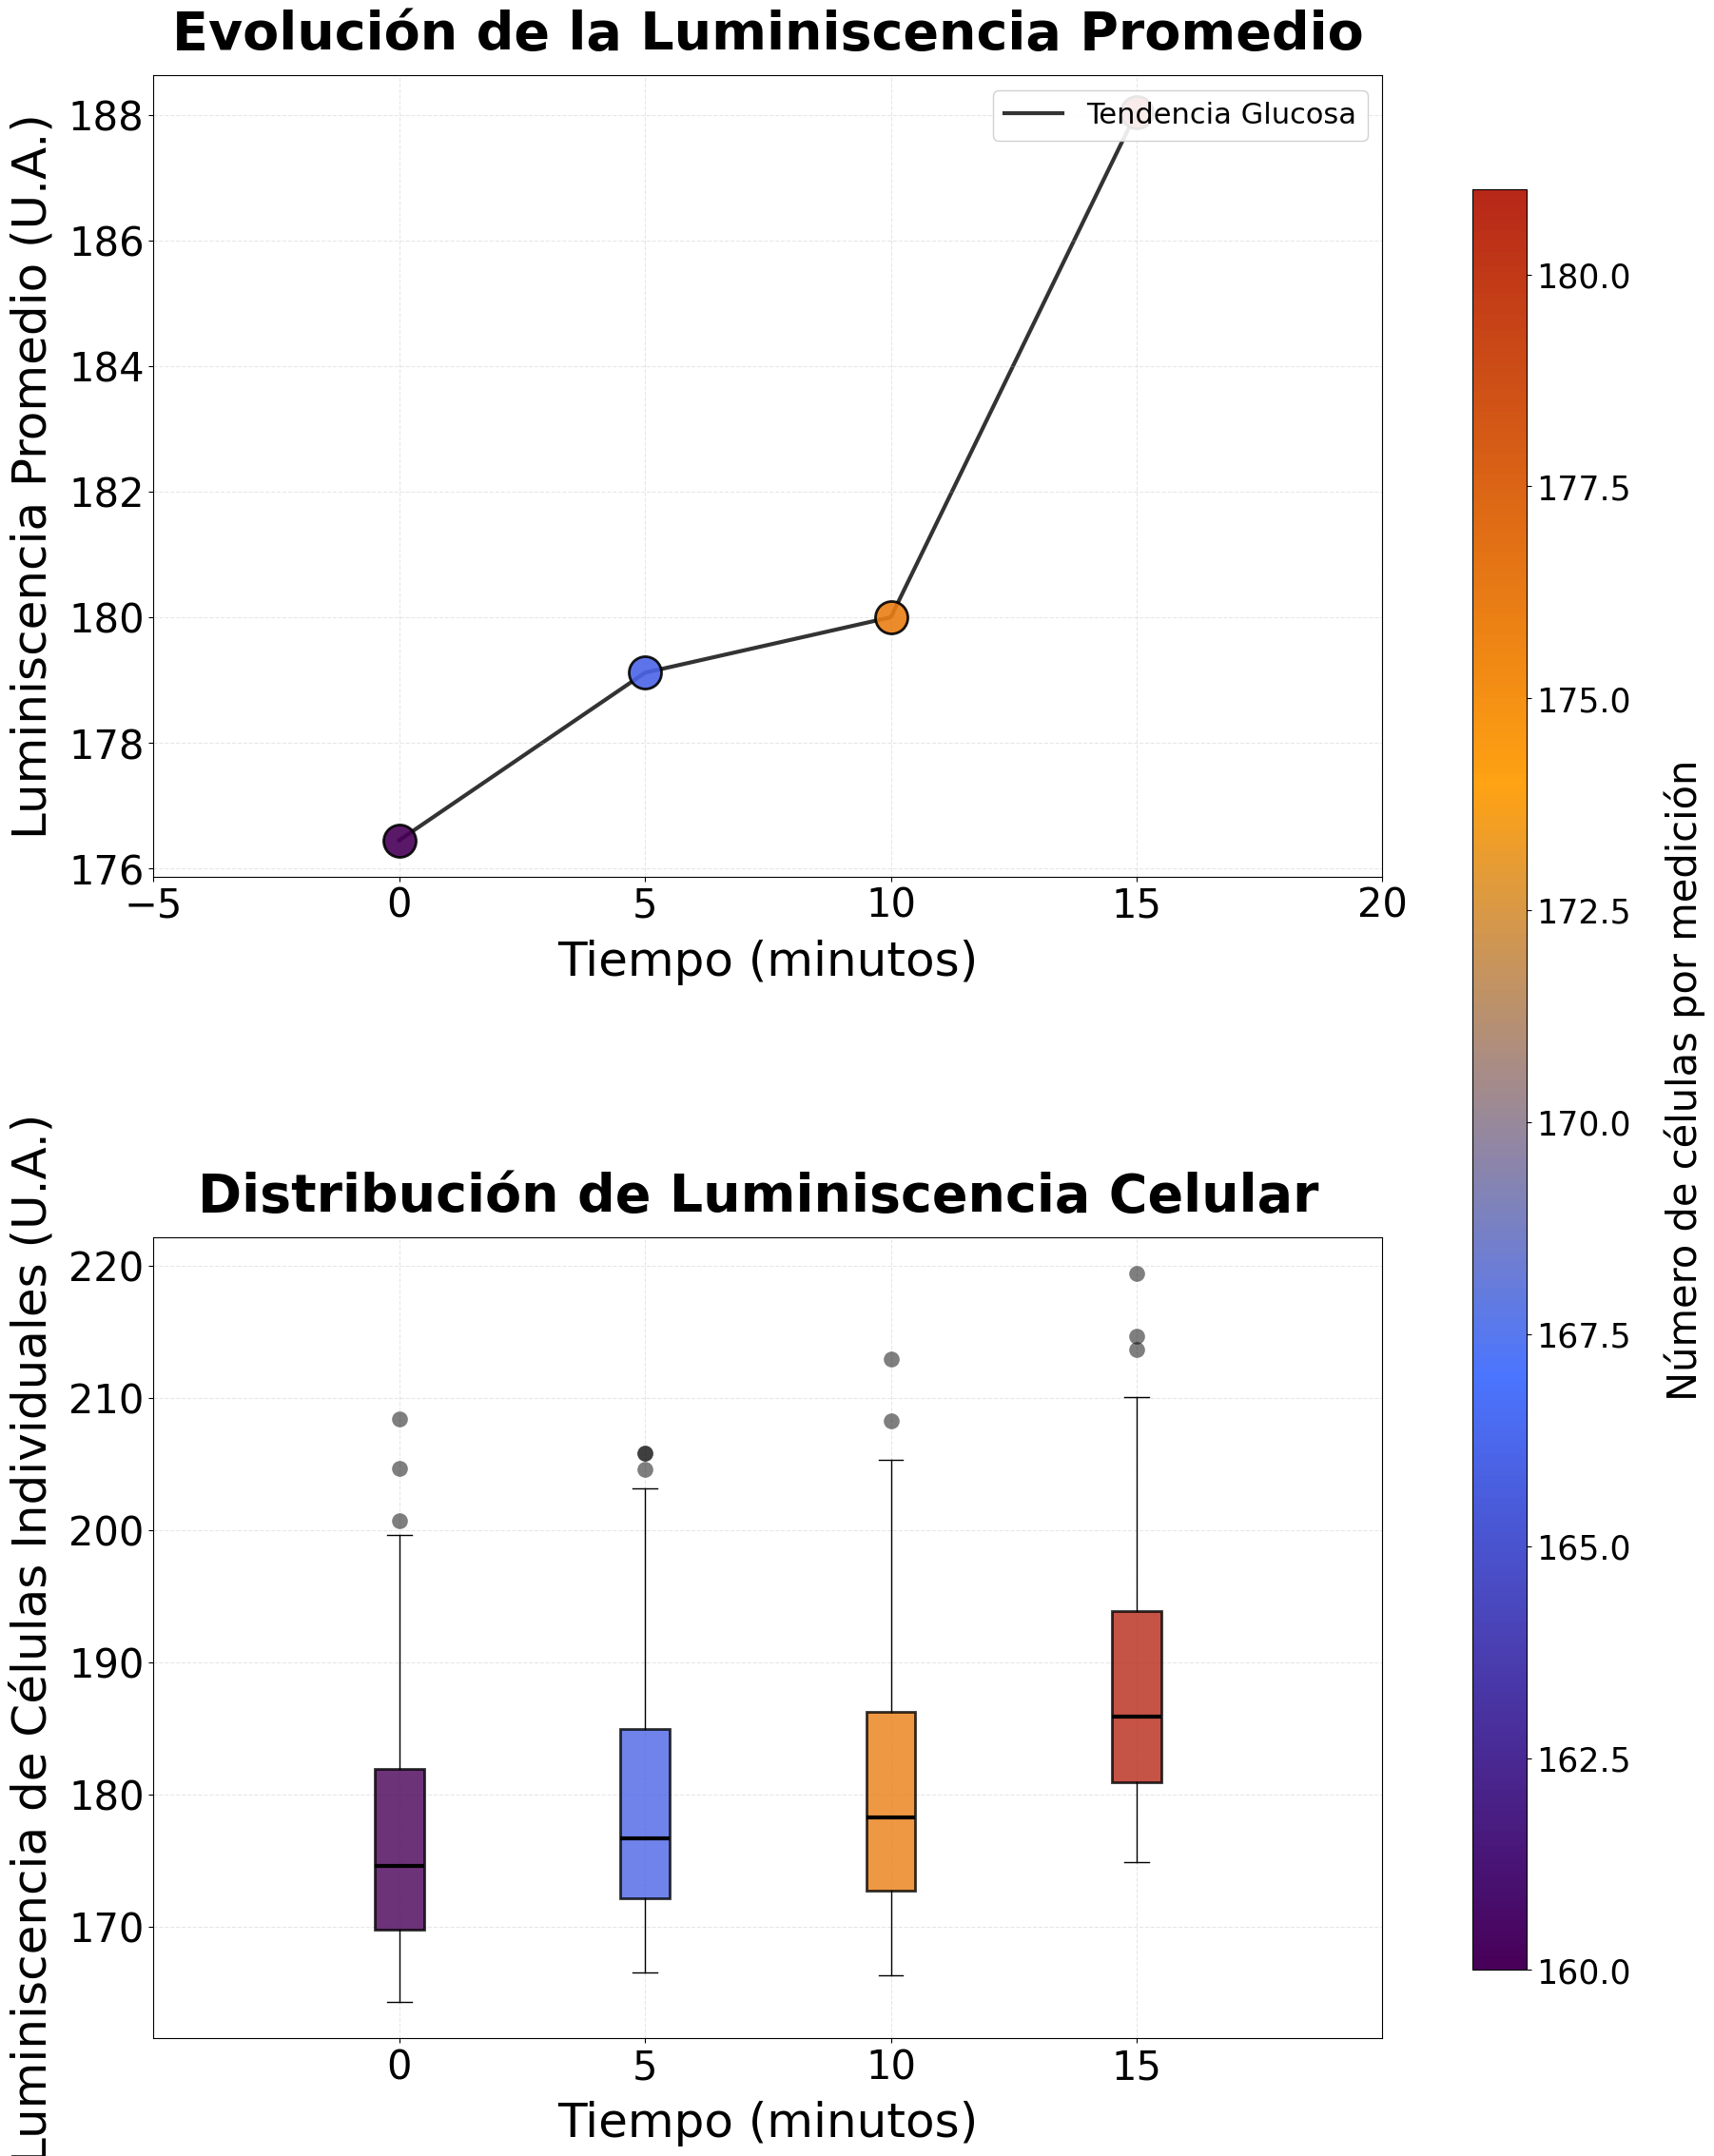

In [39]:
# Llamada pasándole la secuencia temporal completa
grafica_luminicencia_vs_tiempo({'glucosa': [toma1, toma2,toma3,toma4]}, "Glucosa_Tendencia_Area", delta_t=5)

In [ ]:
#hola 
print("hola")